In [215]:
from helpers import *

import os
import re
import numpy as np
import matplotlib. pyplot as plt
from scipy.spatial.distance import directed_hausdorff

In [216]:
nubmer_points_list= [100, 200,300,400,500,600,700,800,900,1000,1100,1200, 1300,1400,1500]
n_runs= [10]

In [217]:
def calculate_distance(point1, point2):
    return sum((x - y) ** 2 for x, y in zip(point1, point2)) ** 0.5

def calculate_tolerance(points):
    num_points = len(points)
    tolerance = 1/num_points
    return tolerance
    
def count_repeated_points(points):
    #points = points[np.lexsort((points[:, 1], points[:, 0]))]
    n= len(points)
    ep=  calculate_tolerance(points)
    distinct_points = []

    for point in points:
        is_distinct = True
        for distinct_point in distinct_points:
            if calculate_distance(point, distinct_point) < ep:
                is_distinct = False
                break
        if is_distinct:
            distinct_points.append(point)
            
    return len(distinct_points), distinct_points

In [218]:
def KS_Test(data, algo):
    
    # Perform K-S test
    ks_statistic, p_value = stats.kstest(data, "uniform")#stats.kstest(ecdf.y, stats.uniform.cdf) #stats.kstest(ecdf.y, cdf_uniform)
    
    print("********START********")
    # Display the results
    print("******KS-Test for {}".format(algo),"*********")
    print(f"K-S Statistic: {ks_statistic}")
    print(f"P-Value: {p_value}")

    # Decision based on the p-value
    alpha = 0.05
    if p_value > alpha:
        print("Fail to reject the null hypothesis: The sample follows the uniform distribution.")
    else:
        print("Reject the null hypothesis: The sample does not follow the uniform distribution.")
    
    print("********END********")

# GSM

In [219]:
main_path = "../GSM/solns_runs/Ex9/"
subfolders = list_subfolders(main_path)

    
txt_files = list_subfolders(subfolders[0])
# list_txt_files(subfolders[0])

titles = [str(100*i) for i in range(1, 16)]

colors = [
    'blue', 'orange', 'r', 'yellow', 'purple',
    'brown', 'pink', 'gray', 'olive', 'cyan', 'red',
    'lightcoral', 'darkgoldenrod', 'mediumseagreen', 'green', 'mangeta'
]


## Number of starting points vs. PDP and HD

In [220]:
# Folders
# folders= {"n_runs_5":["../GSM/solns_runs/Ex1/N_{}/n_runs_5".format(str(pt)) for pt in nubmer_points_list],
#          "n_runs_10":["../GSM/solns_runs/Ex1/N_{}/n_runs_5".format(str(pt)) for pt in nubmer_points_list],
#          "n_runs_15":["../GSM/solns_runs/Ex1/N_{}/n_runs_5".format(str(pt)) for pt in nubmer_points_list],
#          "n_runs_20":["../GSM/solns_runs/Ex1/N_{}/n_runs_5".format(str(pt)) for pt in nubmer_points_list]}

folders= ["../GSM/solns_runs/Ex9/N_{}/".format(str(pt)) for pt in nubmer_points_list]
folders

['../GSM/solns_runs/Ex9/N_100/',
 '../GSM/solns_runs/Ex9/N_200/',
 '../GSM/solns_runs/Ex9/N_300/',
 '../GSM/solns_runs/Ex9/N_400/',
 '../GSM/solns_runs/Ex9/N_500/',
 '../GSM/solns_runs/Ex9/N_600/',
 '../GSM/solns_runs/Ex9/N_700/',
 '../GSM/solns_runs/Ex9/N_800/',
 '../GSM/solns_runs/Ex9/N_900/',
 '../GSM/solns_runs/Ex9/N_1000/',
 '../GSM/solns_runs/Ex9/N_1100/',
 '../GSM/solns_runs/Ex9/N_1200/',
 '../GSM/solns_runs/Ex9/N_1300/',
 '../GSM/solns_runs/Ex9/N_1400/',
 '../GSM/solns_runs/Ex9/N_1500/']

In [221]:
# folders['n_runs_5']

In [222]:
import os

def list_txt_files_in_directory(directory_path):
#     try:
#         # List all files and directories in the specified path
    files_and_directories = os.listdir(directory_path)
#     print(directory_path)
    # Filter and print only .txt files
    txt_files = [file for file in files_and_directories if file.endswith('.txt')]
    txt_files = [file for file in txt_files if '.txt' in file]
    txt_files.sort()
    txt_files= [directory_path+"/"+file for file in txt_files]
        
    return txt_files

In [223]:
n_times= 10
def get_values(folders):
    dist_= []
    avg_hd= []
    for pt in range(len(nubmer_points_list)):
        directory_path = folders[pt]

        files= list_txt_files_in_directory(directory_path)
        if len(files)>n_times:
            files= files[:n_times]
        res= []
        hd= []
        
        num_points= nubmer_points_list[pt]
        
        res_solns= []
        for file in files:
            
            if "._" in file:
                    file= file.replace("._","")
            
            solns= np.genfromtxt(file, delimiter=',')
            res_solns.extend(solns.tolist())
        
        
        res_solns= np.array(res_solns)
        num, distinct_points= count_repeated_points(res_solns)
        distinct_points= np.array(distinct_points)
        
        # Get PDP
        
        dist_.append((len(distinct_points)/(len(res_solns)))*100)
        
        # Get HD:
        
        points0 = [((3-t)/6, (3+t)/6) for t in np.linspace(0, 1, int(len(distinct_points)/3))]
        points = points0
        points= [(0.0,0.0)]+points
        points = np.array(points)

        

        print(len(distinct_points),len(res_solns))
        hausdorff_distance = directed_hausdorff(distinct_points, points)[0]
        avg_hd.append(hausdorff_distance)
        
    # Create subplots with different scales
    fig, ax1 = plt.subplots(figsize=(8, 4))

    # Create second axis with different scale
    ax1.set_xlabel('Number of starting points')
#     ax2 = ax1.twinx()
    ax1.set_ylim([0.0, np.max(dist_)])
    ax1.plot(nubmer_points_list, dist_, 'bo-')
    
#     ax1.set_yticks(dist_)
    
    ax1.set_ylabel('Perentage of distint points',color='blue')
#     ax1.set_ylabel('Perentage of distint points', color='b')


    # Create third axis with different scale
    ax2 = ax1.twinx()
    ax2.spines['right'].set_position(('outward', 60))  # Move the spine to the right
    ax2.plot(nubmer_points_list, avg_hd, 'go-')
    ax2.set_ylabel('Hausdorff Distance', color='g')
    ax2.set_ylim([0.0, np.max(avg_hd)])

    xticks = nubmer_points_list  # Precisely specify xticks from 0 to 10 with a step of 1
    ax1.set_xticks(xticks)
    ax1.set_xticklabels([f'{tick:.0f}' for tick in xticks])  # Format labels as strings with one decimal place


#     plt.savefig('./plots/Metrics/Ex1/ex1_gsm.jpeg')
    plt.savefig('../GSM/solns_runs/Ex9/plot_ex9.png')
# plt.xticks(list(range(len(possible_num_points))),possible_num_points)
    plt.grid(True)
    plt.show()

        
    return dist_,avg_hd

455 1000
907 2000
1359 3000
1847 4000
2286 5000
2739 6000
3178 7000
3665 8000
4137 9000
4552 10000
4989 11000
5478 12000
5922 13000
6408 14000
6810 15000


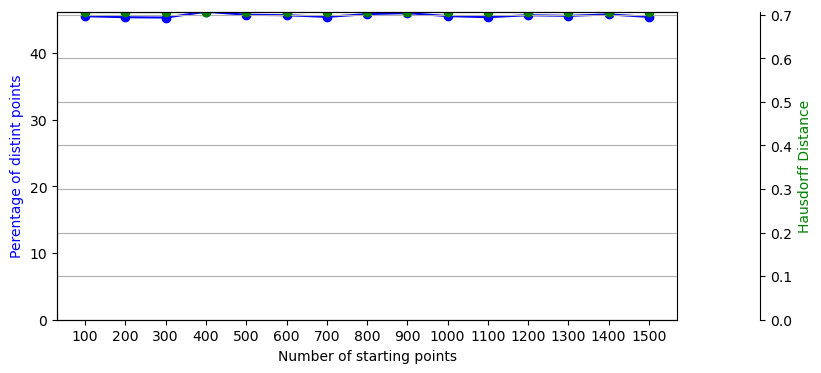

In [224]:
pdpgsm, hdgsm= get_values(folders)

In [225]:
for (p,h) in zip(pdpgsm, hdgsm):
    print(p, " * ", h)

#

45.5  *  0.7064035681930437
45.35  *  0.7063426967918421
45.300000000000004  *  0.7063669537935624
46.175  *  0.7067811609204903
45.72  *  0.7070636471850837
45.65  *  0.7066242654098877
45.4  *  0.7071006691513753
45.8125  *  0.7069545701710783
45.96666666666667  *  0.7071017805904669
45.519999999999996  *  0.7071029642116096
45.35454545454545  *  0.7069628682572713
45.65  *  0.7071006916141108
45.55384615384616  *  0.7070450409360601
45.77142857142857  *  0.7070777765024939
45.4  *  0.7069750906719068


In [226]:
max(pdpgsm), min(hdgsm)

(46.175, 0.7063426967918421)

In [227]:
def plot_solns(folders):
    all_solns= []
    for pt in range(len(nubmer_points_list)):
        directory_path = folders[pt]

        files= list_txt_files_in_directory(directory_path)
        res= []
        for file in files:
            solns= np.genfromtxt(file, delimiter=',')
            num, distinct_points = count_repeated_points(solns)
            distinct_points= np.array(distinct_points)
            res.extend(distinct_points.tolist())
#             break
            
        all_solns.append(res)
        
    
#     print(np.array(all_solns[0])[:,0])
    
    for i in range(len(all_solns)):
        print("Plot for {} points".format(nubmer_points_list[i]))
        plt.scatter(np.array(all_solns[i])[:,0], np.array(all_solns[i])[:,1], c= 'black')
#         plt.xlim([0,1.0])
#         plt.ylim([0,1.0])
        plt.grid(True)
        plt.show()

In [228]:
## Plot solution sets
#plot_solns(folders)

In [229]:
np.argmax(pdpgsm)

3

## Histograms

In [230]:
# n_runs= 50 and 
n_points= nubmer_points_list[np.argmax(pdpgsm)]
print(n_points)
# Best
directory_path = "../GSM/solns_runs/Ex9/N_{}".format(n_points)
all_solnsgsm= []

files= list_txt_files_in_directory(directory_path)
if len(files)>n_times:
    files= files[:n_times]
for file in files:
    solns= np.genfromtxt(file, delimiter=',')

#     num, distinct_points = count_repeated_points(solns)
#     distinct_points= np.array(distinct_points)
    all_solnsgsm.extend(solns.tolist())

all_solnsgsm= np.array(all_solnsgsm)
num, all_solnsgsm = count_repeated_points(all_solnsgsm)
all_solnsgsm= np.array(all_solnsgsm)
print(len(all_solnsgsm))

400
1847


In [231]:
# all_solnsgsm

In [232]:
len(all_solnsgsm)
# print(all_solnsgsm)

1847

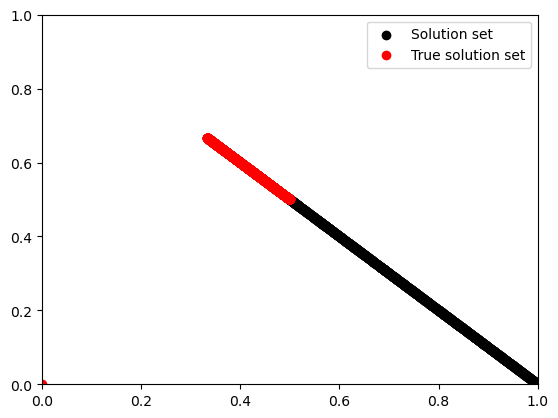

In [233]:
start_point = np.array([1/2, 1/2])
end_point = np.array([1/3, 2/3])
num_points= 1500
t_values = np.linspace(0, 1, num_points)
points = (1 - t_values)[:, np.newaxis] * start_point + t_values[:, np.newaxis] * end_point
points= points.tolist()
points= [(0.0,0.0)]+points
points = np.array(points)

plt.scatter(all_solnsgsm[:,0], all_solnsgsm[:,1], c= 'black', label= "Solution set")
plt.scatter(points[:,0], points[:,1], c= 'r', label= "True solution set")
plt.xlim([0.0,1.0])
plt.ylim([0.0,1.0])
plt.legend()
plt.show()

In [234]:
def partition_interval(a, b, n):
#     n= n-1
    interval_length = b - a
    partition_width = interval_length / n
    partition_points = [a + i * partition_width for i in range(n + 1)]
    return partition_points

def count_values_in_bins(values, bins):
    # Initialize a dictionary to store the counts for each bin
    bin_counts = {bin_index: 0 for bin_index in range(len(bins) - 1)}

    # Iterate over each value
    for value in values:
        # Find the bin that the value falls into
        bin_index = 0
        while bin_index < len(bins) - 1 and not (bins[bin_index] <= value < bins[bin_index + 1]):
            bin_index += 1

        # Increment the count for the corresponding bin.
        if bin_index < len(bins) - 1:
            bin_counts[bin_index] += 1

    return bin_counts

## x:
bins_list= [5, 10, 15, 20]
solns= all_solnsgsm.copy()
x= solns[:,0]
x_min = np.min(x)
x_max = np.max(x)

## y:
y= solns[:,1]
y_min = np.min(y)
y_max = np.max(y)
# y

xgsm= x.copy()
ygsm= y.copy()

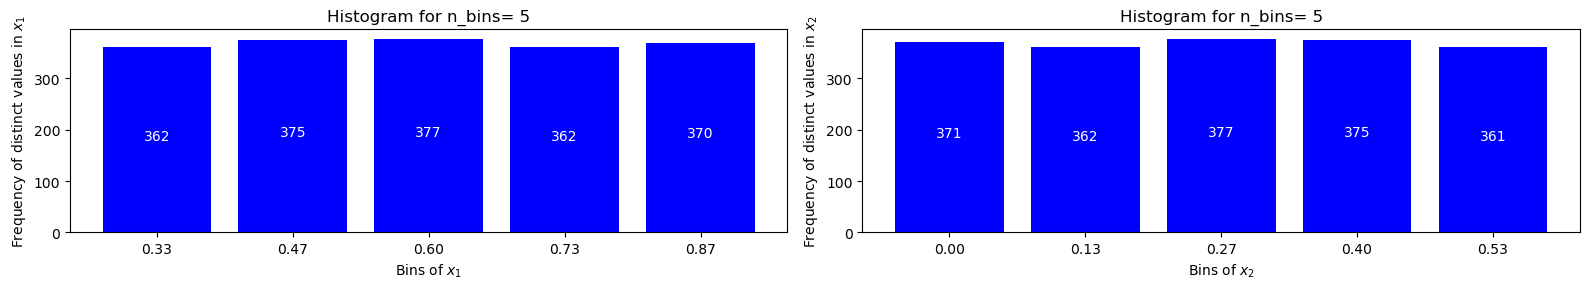

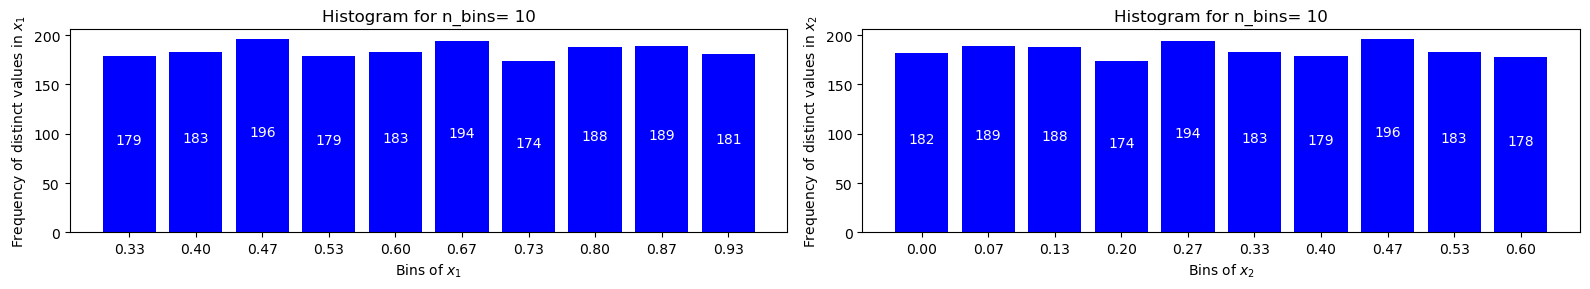

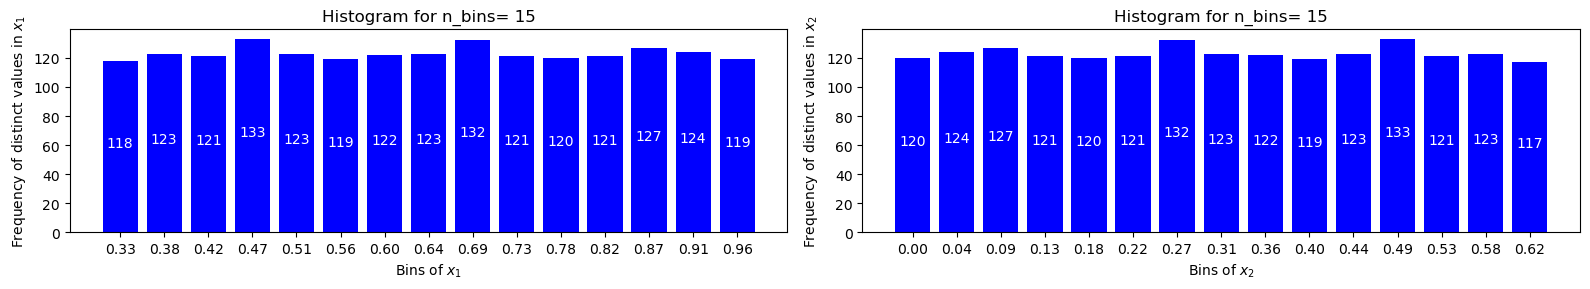

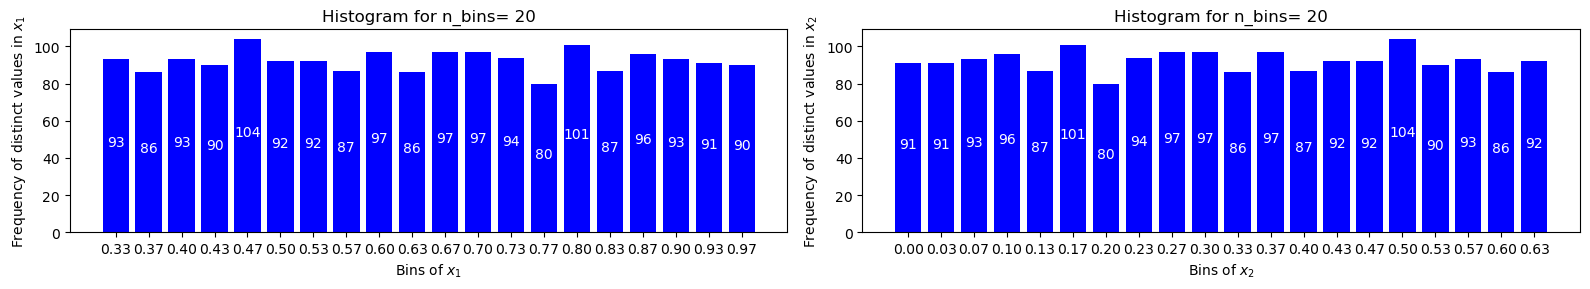

In [235]:
x_hist_gsm= []
y_hist_gsm= []
y_part_gsm= []
x_part_gsm= []
for n_bins in bins_list:
    partition_points = partition_interval(x_min, x_max, n_bins)
    x_part_gsm.append(partition_points)
#     print("Partition points:", partition_points)
    bin_counts = count_values_in_bins(x, partition_points)
    x_hist_gsm.append(bin_counts)
#     bin_counts= get_per(bin_counts)
#     print("Counts in each bin:", bin_counts)

    y_partition_points = partition_interval(y_min, y_max, n_bins)
    y_part_gsm.append(y_partition_points)
    y_bin_counts = count_values_in_bins(y, y_partition_points)
    y_hist_gsm.append(y_bin_counts)
    
#     y_bin_counts= get_per(y_bin_counts)
#     print("Counts in each bin:", y_bin_counts)


    plt.figure(figsize=(16, 3))

    plt.subplot(1, 2, 1)
    bars = plt.bar(range(len(bin_counts)), bin_counts.values(), align='center', color='blue')

    # Annotate each bar with its frequency value
    for i, bar in enumerate(bars):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() / 2, str(int(bin_counts[i])), ha='center', color='white')

    # Customize plot
    plt.xticks(range(len(bin_counts)), ["{:.2f}".format(b) for b in partition_points[:-1]])
    plt.xlabel('Bins of $x_1$')
    plt.ylabel('Frequency of distinct values in $x_1$')
    plt.title('Histogram for n_bins= {}'.format(len(bin_counts)))
#     plt.grid(True)

    plt.subplot(1, 2, 2)
    bars = plt.bar(range(len(y_bin_counts)), y_bin_counts.values(), align='center', color='blue')

    # Annotate each bar with its frequency value
    for i, bar in enumerate(bars):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() / 2, str(int(y_bin_counts[i])), ha='center', color='white')

    # Customize plot
    plt.xticks(range(len(y_bin_counts)), ["{:.2f}".format(b) for b in y_partition_points[:-1]])
    plt.xlabel('Bins of $x_2$')
    plt.ylabel('Frequency of distinct values in $x_2$')
    plt.title('Histogram for n_bins= {}'.format(len(y_bin_counts)))
#     plt.grid(True)
    plt.tight_layout()
    plt.savefig('../GSM/solns_runs/Ex9/'+'ex9_gsm_hist'+str(n_bins)+'.png')
    plt.show()

## Uniform CDF vs. empirical CDF

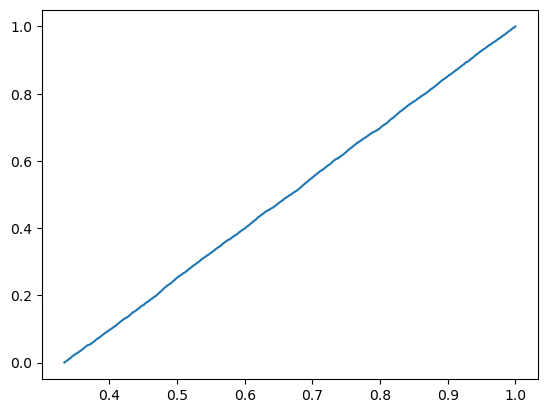

In [236]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from matplotlib import pyplot
from numpy.random import normal
from numpy import hstack
from statsmodels.distributions.empirical_distribution import ECDF
# fit a cdf
ecdf = ECDF(xgsm)
plt.plot(ecdf.x, ecdf.y)
plt.show()


def get_cdf_of_uniform(x, a, b):
    if x<a:
        return 0
    elif a<=x<b:
        return (x-a)/(b-a)
    elif x>b:
        return 1

## KS-Test

In [237]:
import numpy as np
from scipy import stats

# Example data (replace with your actual data)
np.random.seed(0)
data = np.random.uniform(0,1, size=100)

# Perform KS test against a normal distribution (null hypothesis)
ks_statistic, p_value = stats.kstest(data, 'norm')

# Print the results
print(f"KS Statistic: {ks_statistic}")
print(f"P-value: {p_value}")

# Interpret the results
alpha = 0.05
if p_value < alpha:
    print("Reject the null hypothesis that the data is normally distributed.")
else:
    print("Cannot reject the null hypothesis that the data is normally distributed.")


KS Statistic: 0.5018732170965315
P-value: 7.902176095057781e-24
Reject the null hypothesis that the data is normally distributed.


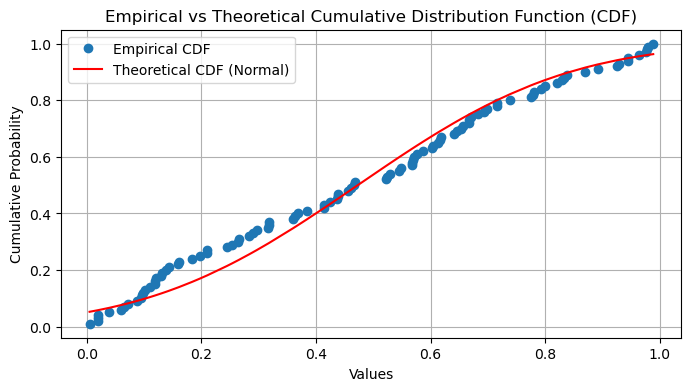

In [238]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Example data (replace with your actual data)
np.random.seed(0)
# data = np.random.normal(loc=0, scale=1, size=100)

# Sort the data
sorted_data = np.sort(data)

# Calculate the empirical CDF
n = sorted_data.size
y_empirical = np.arange(1, n+1) / n

# Calculate the theoretical CDF (normal distribution)
mean, std = np.mean(data), np.std(data)
y_theoretical = stats.norm.cdf(sorted_data, loc=mean, scale=std)

# Plotting the empirical and theoretical CDFs
plt.figure(figsize=(8, 4))
plt.plot(sorted_data, y_empirical, label='Empirical CDF', marker='o', linestyle='none')
plt.plot(sorted_data, y_theoretical, label='Theoretical CDF (Normal)', color='red')
plt.xlabel('Values')
plt.ylabel('Cumulative Probability')
plt.title('Empirical vs Theoretical Cumulative Distribution Function (CDF)')
plt.legend()
plt.grid(True)
plt.show()


In [239]:
start_point = np.array([1/2, 1/2])
end_point = np.array([1/3, 2/3])

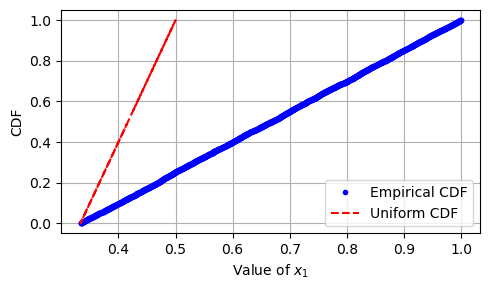

K-S Statistic: 0.3335552528688438
P-Value: 1.0850709207880841e-183
Reject the null hypothesis: The sample does not follow the uniform distribution.


In [240]:
# KS Test on x: 
a,b=end_point[0], start_point[0]
uniform_samples = np.random.uniform(low=a, high=b, size=len(x))
# uniform_samples= np.hstack((uniform_samples,0.0))
cdf_uniform= [get_cdf_of_uniform(i, a= a, b= b) for i in uniform_samples]

# Number of samples
n_samples = len(x)

# Generate uniform values in [0,1]
#uniform_samples = np.random.uniform(low=0.0, high=1.0, size=n_samples)

# Plotting the histogram of uniform samples
plt.figure(figsize=(5, 3))

# CDF Plot
sorted_samples = np.sort(xgsm)
ecdf_gsm_x = ECDF(xgsm) #np.arange(1, n_samples+1) / n_samples
plt.plot(ecdf_gsm_x.x, ecdf_gsm_x.y, marker='.', linestyle='none', label='Empirical CDF',c= 'blue')
# plt.plot([5.0],[1], 'r--')
# plt.plot([0.5, 1], [0.0, 1], 'r--', label='Uniform CDF')
plt.plot(uniform_samples,cdf_uniform, 'r--', label='Uniform CDF')
# plt.title('CDF of Uniform Samples vs. Empiric')
plt.xlabel('Value of $x_1$')
plt.ylabel('CDF')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('../GSM/solns_runs/Ex9/ks_ex9_x1.png')
plt.show()

# Perform K-S test
ks_statistic, p_value = stats.kstest(xgsm, "uniform")#stats.kstest(ecdf.y, stats.uniform.cdf) #stats.kstest(ecdf.y, cdf_uniform)

# Display the results
print(f"K-S Statistic: {ks_statistic}")
print(f"P-Value: {p_value}")

# Decision based on the p-value
alpha = 0.05
if p_value > alpha:
    print("Fail to reject the null hypothesis: The sample follows the uniform distribution.")
else:
    print("Reject the null hypothesis: The sample does not follow the uniform distribution.")

In [241]:
1/3

0.3333333333333333

In [242]:
ecdf_gsm_x.x

array([      -inf, 0.33355525, 0.3339904 , ..., 0.99887846, 0.99925149,
       0.99976975])

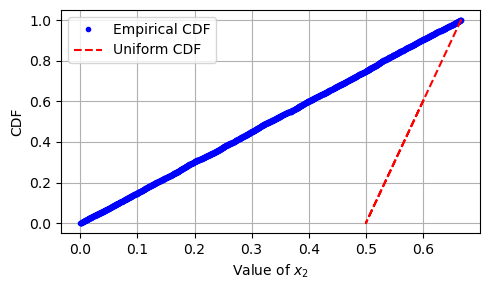

K-S Statistic: 0.3335552528688438
P-Value: 1.0850709207880841e-183
Reject the null hypothesis: The sample does not follow the uniform distribution.


In [243]:
# KS Test on y: 
# Number of samples
a,b= 1/2, 2/3
uniform_samples = np.random.uniform(low=a, high=b, size=len(x))
cdf_uniform= [get_cdf_of_uniform(i, a= a, b= b) for i in uniform_samples]

n_samples = len(x)
plt.figure(figsize=(5, 3))

# CDF Plot
sorted_samples = np.sort(ygsm)
ecdf_gsm_y = ECDF(ygsm) # np.arange(1, n_samples+1) / n_samples
plt.plot(ecdf_gsm_y.x, ecdf_gsm_y.y, marker='.', linestyle='none', label='Empirical CDF', c= 'blue')
# plt.plot([1-1, 1-0.5], [1-1, 1], 'r--', label='Uniform CDF')
plt.plot(uniform_samples, cdf_uniform, 'r--', label='Uniform CDF')
# plt.title('CDF of Uniform Samples')
plt.xlabel('Value of $x_2$')
plt.ylabel('CDF')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('../GSM/solns_runs/Ex9/ks_ex9_x2.png')
plt.show()

# Perform K-S test
ks_statistic, p_value = stats.kstest(ygsm, "uniform")

# Display the results
print(f"K-S Statistic: {ks_statistic}")
print(f"P-Value: {p_value}")

# Decision based on the p-value
alpha = 0.05
if p_value > alpha:
    print("Fail to reject the null hypothesis: The sample follows the uniform distribution.")
else:
    print("Reject the null hypothesis: The sample does not follow the uniform distribution.")


# PVI

In [244]:
nubmer_points_list= [100, 200, 300, 400, 500, 600, 700, 800, 900, 1000, 1100, 1200, 1300, 1400, 1500]

In [245]:
from math import *
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize_scalar


import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize_scalar


# Define objective functions for each player
def player1_objective(x):
    return -x[0]

def player2_objective(x):
    return -x[1]


# Define constraints for each player
def constraint_function1(x):
    return 1-(x[0]+x[1])

def constraint_function2(x):
    return -(-2*x[0]+x[1])

def constraint_function(x):
  return np.array([constraint_function1(x),constraint_function2(x)])

In [246]:
# New

## Load data

import json


with open('../Scripts/PVI/Ex8PVIT.json') as f:
    dataT= json.load(f)

T_list= [1, 2, 3, 4, 5, 6, 7, 8, 9]
data_dict= dict.fromkeys(range(1, len(T_list)+1), 0)

data_dict



for T in T_list:
    data_all= []

    for i in range(len(nubmer_points_list)):
        res_= []

        if len(dataT[str(T)][i])== 0:
            # print(dataT[str(1)][i])
            data_all.append([dataT[str(T)][i]])
            # res_.append([dataT[str(1)][i]])
        else:
            
            for t in range(len(dataT[str(T)][i])):
                res_.append(dataT[str(T)][i][t])
                #if np.abs(constraint_function(dataT[str(T)][i][t]))<= 1e-6:
                # if  np.all(np.abs(constraint_function(dataT[str(T)][i][t]))<=1e-4):
                #     res_.append(dataT[str(T)][i][t])
            data_all.append(res_)
    data_dict[T]= data_all


res_all= []

for i in range(len(nubmer_points_list)):
    res= []
    for T in T_list:
        res.extend(data_dict[T][i])

    res_all.append(res)

In [247]:
data_all= res_all

In [248]:
data_all

[[[0.68557053300942, 0.3144258294772253],
  [0.33333333957231276, 0.6666666604276872],
  [0.3333333333333333, 0.6666666666666666],
  [0.33333333333333337, 0.6666666666666666],
  [0.3333333333333333, 0.6666666666666666],
  [0.33333333333333337, 0.6666666666666666],
  [0.3333333333333332, 0.6666666666666667],
  [0.33333333333333337, 0.6666666666666666],
  [0.3333333333333333, 0.6666666666666667],
  [0.33333333333333337, 0.6666666666666666],
  [0.33333334288893696, 0.666666657111063],
  [0.3333333490220096, 0.6666666509779904],
  [0.23050291172652207, 0.4610058134531414],
  [0.3333333333333333, 0.6666666666666666],
  [0.3333333333333333, 0.6666666666666666],
  [0.3333333429890728, 0.6666666570109272],
  [0.33333333333333326, 0.6666666666666666],
  [0.33333333333333337, 0.6666666666666666],
  [0.3333333333333334, 0.6666666666666666],
  [0.3333333333333333, 0.6666666666666666],
  [0.4192063074455211, 0.5807892808970997],
  [0.3333333440563435, 0.6666666559436565],
  [0.3333333333333333, 0.6

In [249]:
data= []
dist_= []
avg_hd= []

for (idx, pt) in enumerate(nubmer_points_list):
    print(pt)
    dt= []
    

    num_points= nubmer_points_list[idx]

    num, distinct_points = count_repeated_points(np.array(data_all[idx]))
    # print(len(distinct_points), len(np.array(data_all[idx])))
    distinct_points= np.array(distinct_points)  

    points0 = [((3-t)/6, (3+t)/6) for t in np.linspace(0, 1, int(len(distinct_points)/3))]
    points = points0
    points= [(0.0,0.0)]+points
    points = np.array(points)
    
    
    hausdorff_distance = directed_hausdorff(np.array(data_all[idx]), points)[0]
    dist_.append((len(distinct_points)/(len(data_all[idx])))*100) 
    # dist_.append(len(distinct_points)/len(data_all[idx])) 
    avg_hd.append(hausdorff_distance)

100
200
300
400
500
600
700
800
900
1000
1100
1200
1300
1400
1500


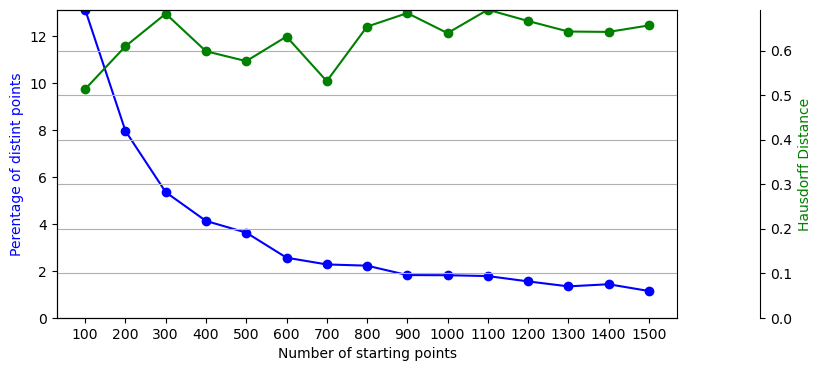

In [250]:
fig, ax1 = plt.subplots(figsize=(8, 4))

# Create second axis with different scale
ax1.set_xlabel('Number of starting points')
#     ax2 = ax1.twinx()
ax1.set_ylim([0.0, np.max(dist_)])
ax1.plot(nubmer_points_list, dist_, 'bo-')
    
#     ax1.set_yticks(dist_)
    
ax1.set_ylabel('Perentage of distint points',color='blue')
#     ax1.set_ylabel('Perentage of distint points', color='b')


# Create third axis with different scale
ax2 = ax1.twinx()
ax2.spines['right'].set_position(('outward', 60))  # Move the spine to the right
ax2.plot(nubmer_points_list, avg_hd, 'go-')
ax2.set_ylabel('Hausdorff Distance', color='g')
ax2.set_ylim([0.0, np.max(avg_hd)])

xticks = nubmer_points_list  # Precisely specify xticks from 0 to 10 with a step of 1
ax1.set_xticks(xticks)
ax1.set_xticklabels([f'{tick:.0f}' for tick in xticks])  # Format labels as strings with one decimal place


plt.savefig('../PVI/solns_runs/Ex9/plot_ex9.png')
plt.grid(True)
plt.show()

In [251]:
pdppvi, hdgpvi= dist_.copy(),avg_hd.copy()

In [252]:
pdppvi

[13.137254901960786,
 7.964601769911504,
 5.354558610709118,
 4.127682993946065,
 3.6297640653357535,
 2.5612472160356345,
 2.272727272727273,
 2.2203719122953096,
 1.8195413758723826,
 1.812758145938504,
 1.7772266997313495,
 1.5493233967444597,
 1.3371367445177393,
 1.4280969777482564,
 1.1404028436018958]

In [253]:
hdgpvi

[0.5135868575546135,
 0.6096619609587968,
 0.6828140988741038,
 0.5984873059157457,
 0.5763163901764358,
 0.6314915310457175,
 0.5313024073211967,
 0.6537990471289373,
 0.6842439540365546,
 0.6392144361038146,
 0.6917866040258943,
 0.6664508876078478,
 0.6427906338048492,
 0.6419743532847197,
 0.656500464115692]

In [254]:
for (p,h) in zip(pdppvi,hdgpvi):
    print(p, " *** ", h)

13.137254901960786  ***  0.5135868575546135
7.964601769911504  ***  0.6096619609587968
5.354558610709118  ***  0.6828140988741038
4.127682993946065  ***  0.5984873059157457
3.6297640653357535  ***  0.5763163901764358
2.5612472160356345  ***  0.6314915310457175
2.272727272727273  ***  0.5313024073211967
2.2203719122953096  ***  0.6537990471289373
1.8195413758723826  ***  0.6842439540365546
1.812758145938504  ***  0.6392144361038146
1.7772266997313495  ***  0.6917866040258943
1.5493233967444597  ***  0.6664508876078478
1.3371367445177393  ***  0.6427906338048492
1.4280969777482564  ***  0.6419743532847197
1.1404028436018958  ***  0.656500464115692


In [255]:
max(pdppvi), min(hdgpvi)

(13.137254901960786, 0.5135868575546135)

In [256]:
pdppvi_all, hdgpvi_all= dist_.copy(),avg_hd.copy()

In [257]:
nubmer_points_list[9:]

[1000, 1100, 1200, 1300, 1400, 1500]

In [258]:
pdppvi_all

[13.137254901960786,
 7.964601769911504,
 5.354558610709118,
 4.127682993946065,
 3.6297640653357535,
 2.5612472160356345,
 2.272727272727273,
 2.2203719122953096,
 1.8195413758723826,
 1.812758145938504,
 1.7772266997313495,
 1.5493233967444597,
 1.3371367445177393,
 1.4280969777482564,
 1.1404028436018958]

In [259]:
hdgpvi_all

[0.5135868575546135,
 0.6096619609587968,
 0.6828140988741038,
 0.5984873059157457,
 0.5763163901764358,
 0.6314915310457175,
 0.5313024073211967,
 0.6537990471289373,
 0.6842439540365546,
 0.6392144361038146,
 0.6917866040258943,
 0.6664508876078478,
 0.6427906338048492,
 0.6419743532847197,
 0.656500464115692]

In [260]:
r= []
data= data_all
for i in range(len(data_all)):
    #total= ()/(50)
    print(len(data_all[i]), len(data[i]), "Ratio: ", len(data[i])/len(data_all[i]))
    r.append(len(data[i])/len(data_all[i]))

510 510 Ratio:  1.0
904 904 Ratio:  1.0
1382 1382 Ratio:  1.0
1817 1817 Ratio:  1.0
2204 2204 Ratio:  1.0
2694 2694 Ratio:  1.0
3124 3124 Ratio:  1.0
3603 3603 Ratio:  1.0
4012 4012 Ratio:  1.0
4358 4358 Ratio:  1.0
4839 4839 Ratio:  1.0
5099 5099 Ratio:  1.0
5609 5609 Ratio:  1.0
6022 6022 Ratio:  1.0
6752 6752 Ratio:  1.0


In [154]:
r

[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]

In [261]:
# # Best npoint
sol= np.array(data[np.argmax(pdppvi)])
# print(sol)
num, distinct_points = count_repeated_points(sol)
solnspvi= np.array(distinct_points)
print(solnspvi)

[[0.68557053 0.31442583]
 [0.33333334 0.66666666]
 [0.23050291 0.46100581]
 [0.41920631 0.58078928]
 [0.44354486 0.55645062]
 [0.4556813  0.54431414]
 [0.20167626 0.093731  ]
 [0.50474098 0.49525439]
 [0.08373947 0.16747893]
 [0.44904821 0.55094725]
 [0.35082244 0.64917361]
 [0.76765088 0.23234619]
 [0.5443607  0.32639886]
 [0.26433706 0.09118998]
 [0.27438752 0.54877503]
 [0.56921744 0.43077809]
 [0.86315974 0.13683824]
 [0.63723873 0.36275722]
 [0.39479799 0.39249375]
 [0.71180389 0.28819271]
 [0.49593918 0.23338434]
 [0.23157675 0.22796367]
 [0.73811695 0.26187988]
 [0.60870477 0.20258563]
 [0.21237305 0.02497608]
 [0.85317247 0.14682543]
 [0.37775858 0.62223724]
 [0.36673478 0.63326113]
 [0.24701832 0.49403663]
 [0.58332929 0.41666632]
 [0.40123722 0.59875847]
 [0.85871762 0.14128032]
 [0.60472995 0.39526578]
 [0.48880294 0.51119243]
 [0.66419539 0.33580078]
 [0.62868489 0.371311  ]
 [0.29705356 0.4318518 ]
 [0.76904871 0.2218439 ]
 [0.6545939  0.3454022 ]
 [0.618272   0.38172382]


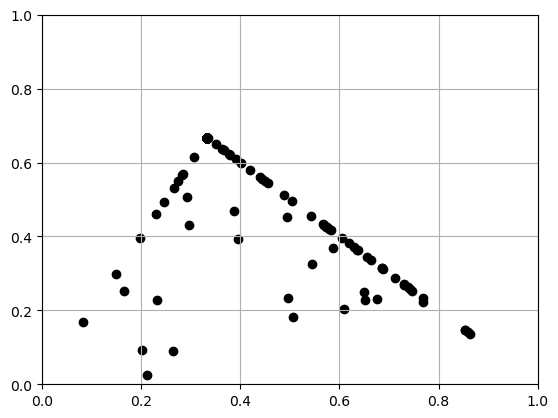

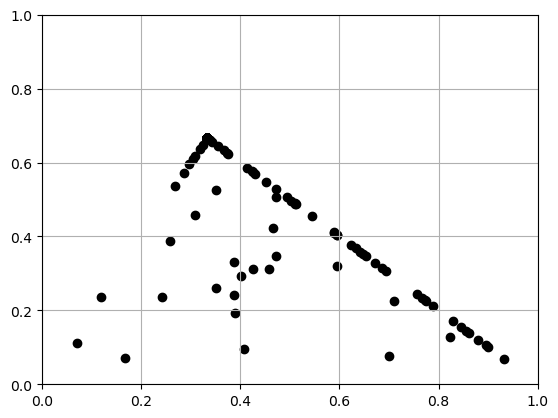

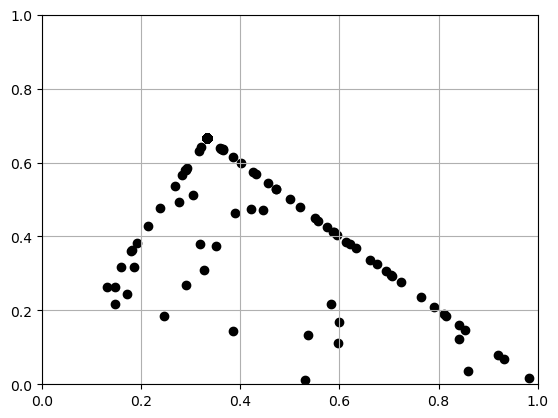

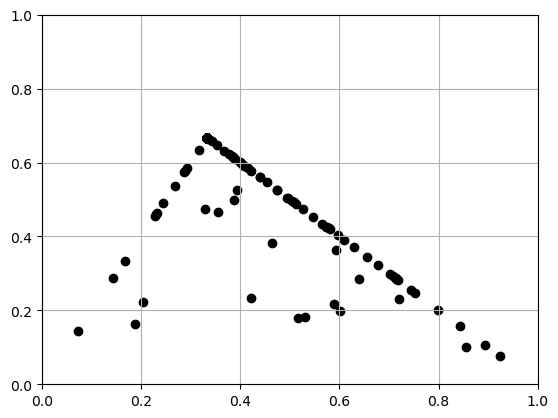

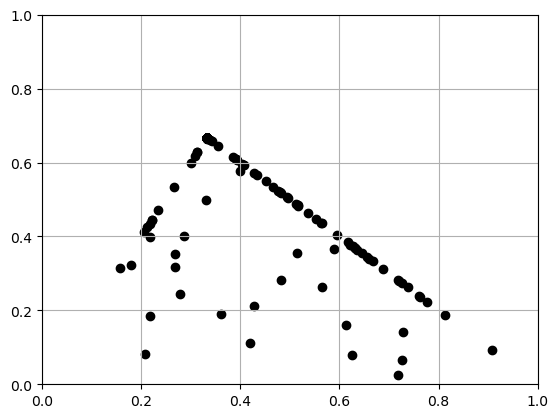

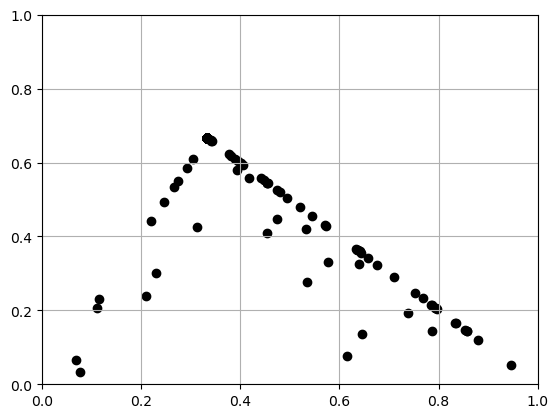

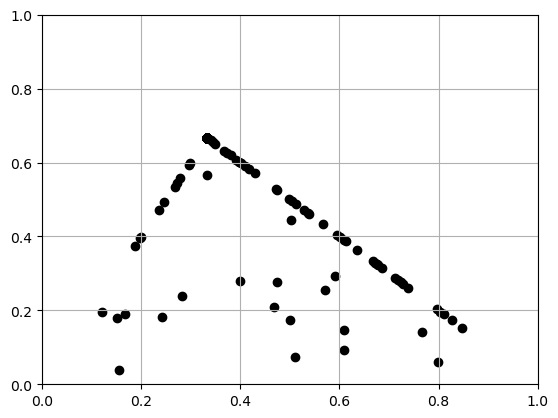

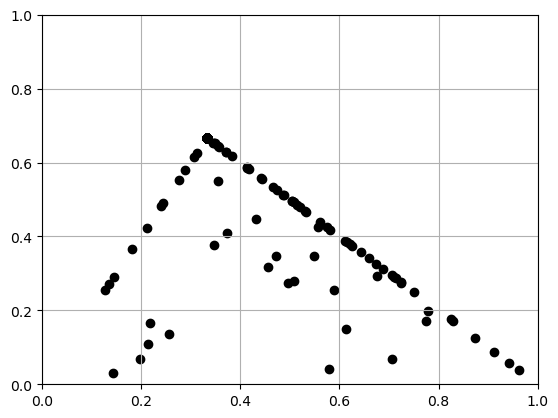

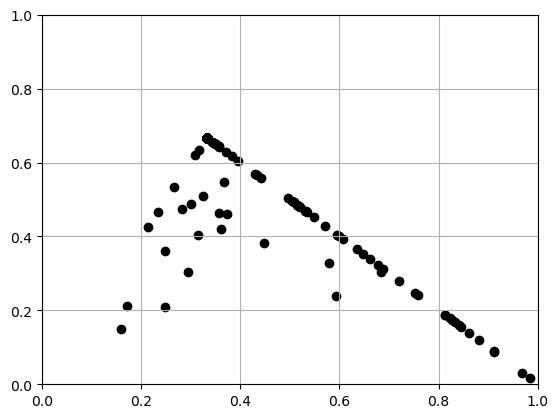

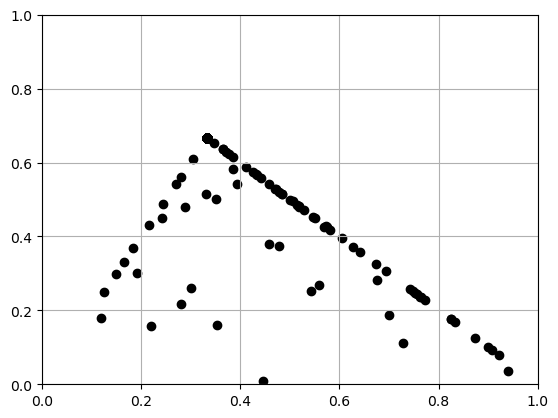

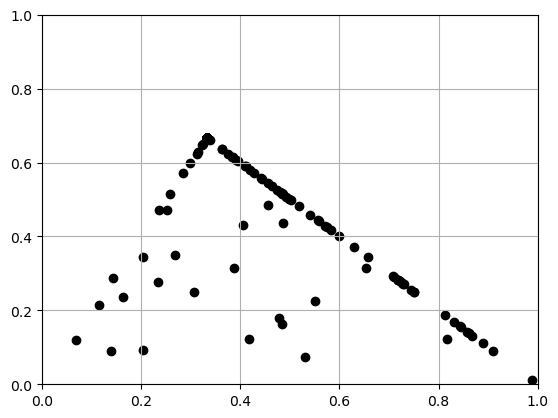

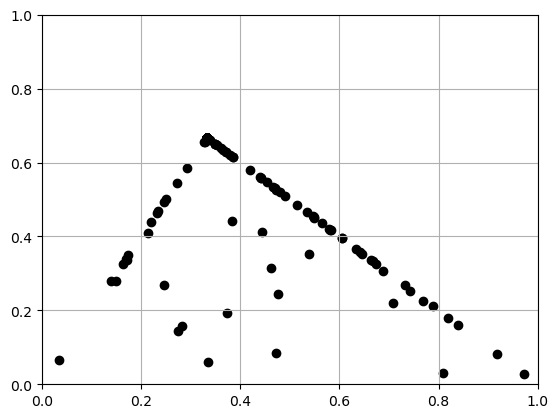

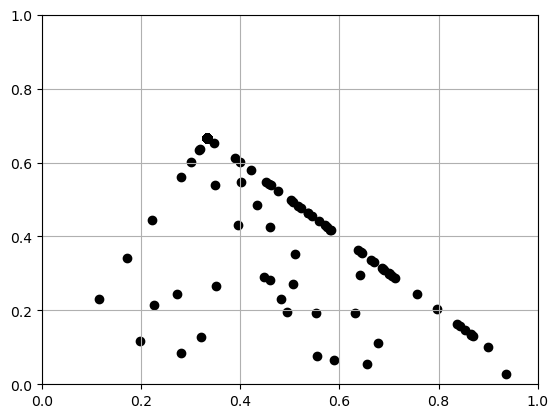

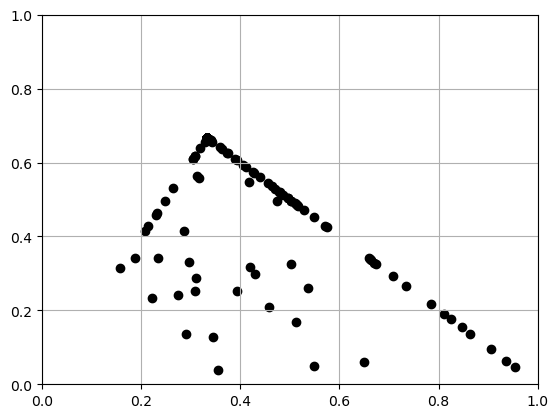

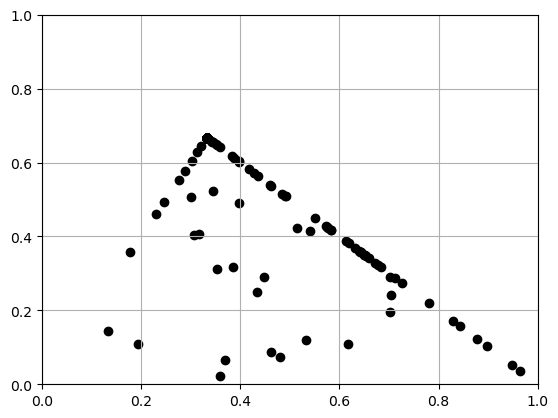

In [262]:
for i in range(len(nubmer_points_list)):
    sol= np.array(data[i])
    plt.scatter(sol[:,0], sol[:,1], c= 'black')
    plt.xlim([0,1.0])
    plt.ylim([0,1.0])
    plt.grid(True)
    plt.show()

## Histogram

In [263]:
# # PVI
# solnspvi=  np.array(data[14]) #np.genfromtxt("../PVI/Ex5"+"/"+"solnsEx5.txt", delimiter=',') #np.array(solns) #sol

# num, distinct_points = count_repeated_points(solnspvi)
# solnspvi= np.array(distinct_points)
# solnspvi

In [264]:
## x:
bins_list= [5, 10, 15, 20]
solns= solnspvi.copy()
x= solns[:,0]
x_min = np.min(x)
x_max = np.max(x)

## y:
y= solns[:,1]
y_min = np.min(y)
y_max = np.max(y)
# y

xpvi= x.copy()
ypvi= y.copy()

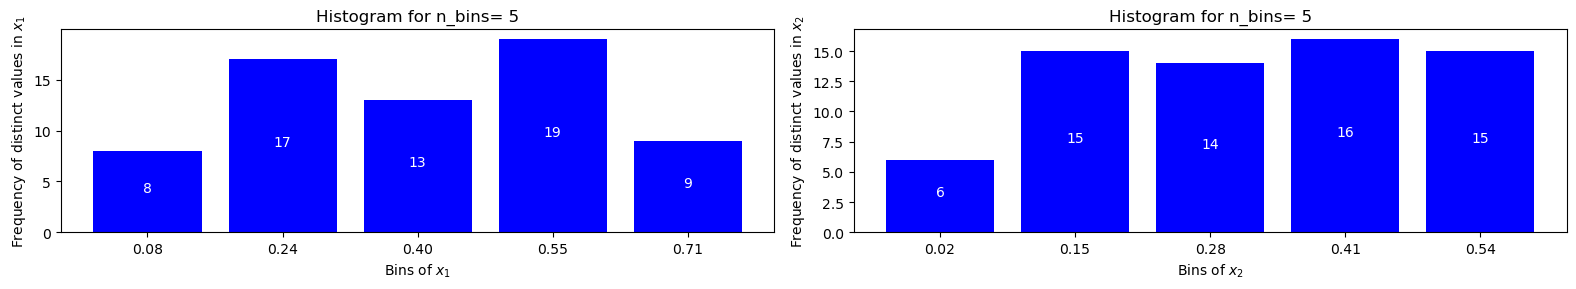

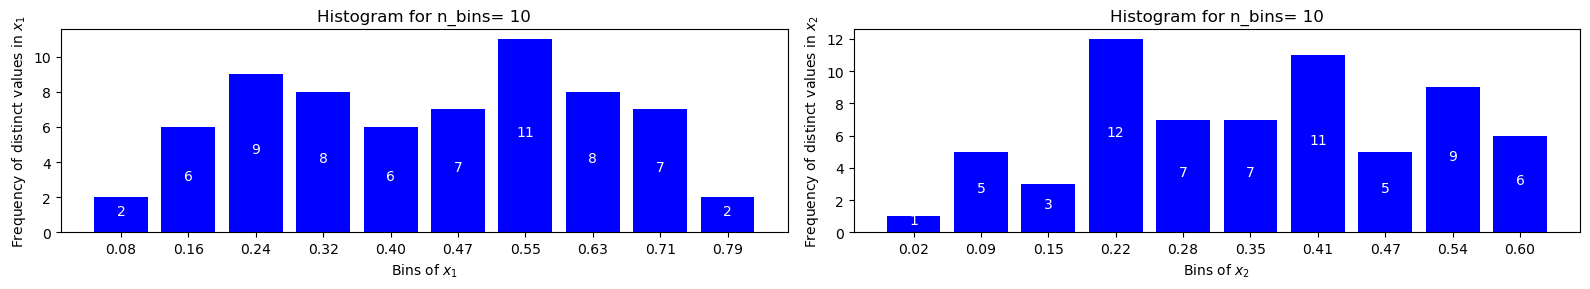

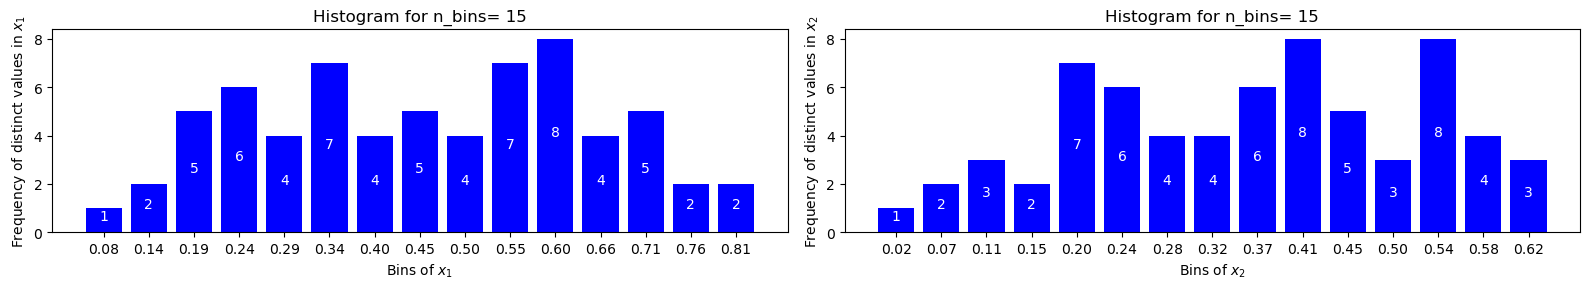

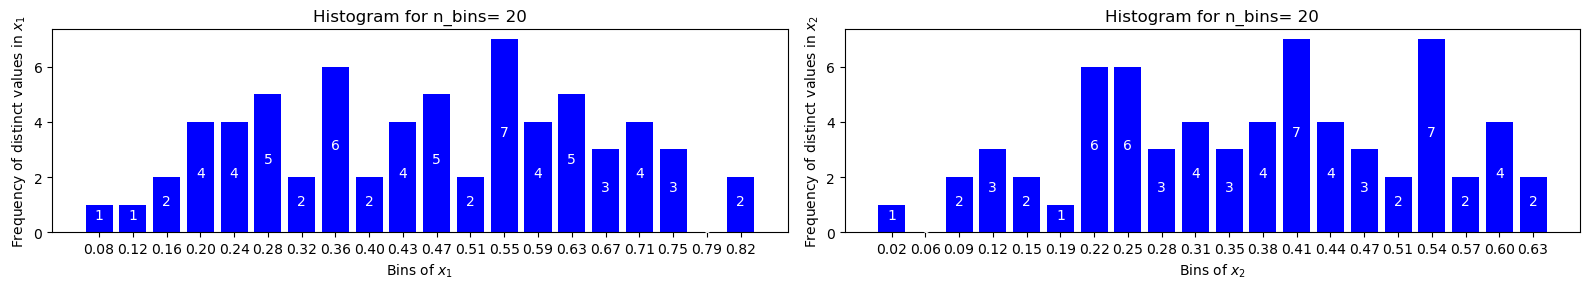

In [265]:
x_hist_pvi= []
y_hist_pvi= []
y_part_pvi= []
x_part_pvi= []
for n_bins in bins_list:
    partition_points = partition_interval(x_min, x_max, n_bins)
    x_part_pvi.append(partition_points)
#     print("Partition points:", partition_points)
    bin_counts = count_values_in_bins(x, partition_points)
    x_hist_pvi.append(bin_counts)
#     bin_counts= get_per(bin_counts)
#     print("Counts in each bin:", bin_counts)

    y_partition_points = partition_interval(y_min, y_max, n_bins)
    y_part_pvi.append(y_partition_points)
    y_bin_counts = count_values_in_bins(y, y_partition_points)
    y_hist_pvi.append(y_bin_counts)
    
#     y_bin_counts= get_per(y_bin_counts)
#     print("Counts in each bin:", y_bin_counts)


    plt.figure(figsize=(16, 3))

    plt.subplot(1, 2, 1)
    bars = plt.bar(range(len(bin_counts)), bin_counts.values(), align='center', color='blue')

    # Annotate each bar with its frequency value
    for i, bar in enumerate(bars):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() / 2, str(int(bin_counts[i])), ha='center', color='white')

    # Customize plot
    plt.xticks(range(len(bin_counts)), ["{:.2f}".format(b) for b in partition_points[:-1]])
    plt.xlabel('Bins of $x_1$')
    plt.ylabel('Frequency of distinct values in $x_1$')
    plt.title('Histogram for n_bins= {}'.format(len(bin_counts)))
#     plt.grid(True)

    plt.subplot(1, 2, 2)
    bars = plt.bar(range(len(y_bin_counts)), y_bin_counts.values(), align='center', color='blue')

    # Annotate each bar with its frequency value
    for i, bar in enumerate(bars):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() / 2, str(int(y_bin_counts[i])), ha='center', color='white')

    # Customize plot
    plt.xticks(range(len(y_bin_counts)), ["{:.2f}".format(b) for b in y_partition_points[:-1]])
    plt.xlabel('Bins of $x_2$')
    plt.ylabel('Frequency of distinct values in $x_2$')
    plt.title('Histogram for n_bins= {}'.format(len(y_bin_counts)))
#     plt.grid(True)
    plt.tight_layout()
    plt.savefig('../PVI/solns_runs/Ex9/'+'ex9_pvi_hist'+str(n_bins)+'.png')
    plt.show()

## Uniform CDF vs. empirical CDF and KS-Test

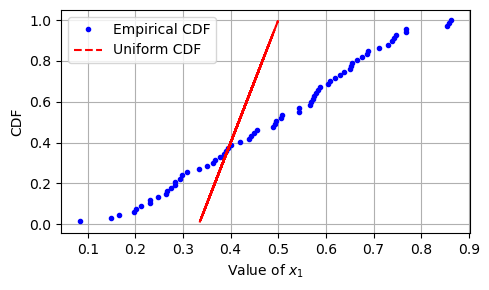

K-S Statistic: 0.18617517036769393
P-Value: 0.016614925530707425
Reject the null hypothesis: The sample does not follow the uniform distribution.


In [266]:
# KS Test on x: 
a,b= end_point[0], start_point[0]
uniform_samples = np.random.uniform(low=a, high=b, size=len(xpvi))
cdf_uniform= [get_cdf_of_uniform(i, a= a, b= b) for i in uniform_samples]

# Number of samples
n_samples = len(xpvi)

# Generate uniform values in [0,1]
#uniform_samples = np.random.uniform(low=0.0, high=1.0, size=n_samples)

# Plotting the histogram of uniform samples
plt.figure(figsize=(5, 3))

# CDF Plot
sorted_samples = np.sort(xpvi)
ecdf_pvi_x = ECDF(xpvi) #np.arange(1, n_samples+1) / n_samples
plt.plot(ecdf_pvi_x.x, ecdf_pvi_x.y, marker='.', linestyle='none', label='Empirical CDF',c= 'blue')
# plt.plot([0.5, 1], [0.0, 1], 'r--', label='Uniform CDF')
plt.plot(uniform_samples,cdf_uniform, 'r--', label='Uniform CDF')
# plt.title('CDF of Uniform Samples vs. Empiric')
plt.xlabel('Value of $x_1$')
plt.ylabel('CDF')
plt.legend()
plt.grid(True)
plt.tight_layout()
# plt.savefig('../PVI/solns_runs/Ex4/ks_ex4_x1.png')
plt.show()

# Perform K-S test
ks_statistic, p_value = stats.kstest(xpvi, "uniform")#stats.kstest(ecdf.y, stats.uniform.cdf) #stats.kstest(ecdf.y, cdf_uniform)

# Display the results
print(f"K-S Statistic: {ks_statistic}")
print(f"P-Value: {p_value}")

# Decision based on the p-value
alpha = 0.05
if p_value > alpha:
    print("Fail to reject the null hypothesis: The sample follows the uniform distribution.")
else:
    print("Reject the null hypothesis: The sample does not follow the uniform distribution.")

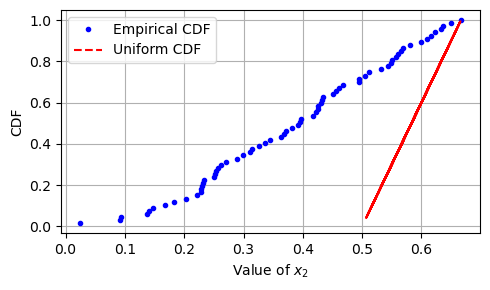

K-S Statistic: 0.3359010182606077
P-Value: 3.035226592237184e-07
Reject the null hypothesis: The sample does not follow the uniform distribution.


In [267]:
# KS Test on y: 
# Number of samples
a,b=  1/2, 2/3
uniform_samples = np.random.uniform(low=a, high=b, size=len(ypvi))
cdf_uniform= [get_cdf_of_uniform(i, a= a, b= b) for i in uniform_samples]

n_samples = len(ypvi)
plt.figure(figsize=(5, 3))

# CDF Plot
sorted_samples = np.sort(ypvi)
ecdf_gsm_y = ECDF(ypvi) # np.arange(1, n_samples+1) / n_samples
plt.plot(ecdf_gsm_y.x, ecdf_gsm_y.y, marker='.', linestyle='none', label='Empirical CDF', c= 'blue')
# plt.plot([1-1, 1-0.5], [1-1, 1], 'r--', label='Uniform CDF')
plt.plot(uniform_samples, cdf_uniform, 'r--', label='Uniform CDF')
# plt.title('CDF of Uniform Samples')
plt.xlabel('Value of $x_2$')
plt.ylabel('CDF')
plt.legend()
plt.grid(True)
plt.tight_layout()
# plt.savefig('../PVI/solns_runs/Ex4/ks_ex4_x2.png')
plt.show()

# Perform K-S test
ks_statistic, p_value = stats.kstest(ypvi, "uniform")

# Display the results
print(f"K-S Statistic: {ks_statistic}")
print(f"P-Value: {p_value}")

# Decision based on the p-value
alpha = 0.05
if p_value > alpha:
    print("Fail to reject the null hypothesis: The sample follows the uniform distribution.")
else:
    print("Reject the null hypothesis: The sample does not follow the uniform distribution.")


### Number of starting points vs. PDP and HD

# BFGS

In [268]:
def list_subfolders(folder_path):
    subfolders = [f.path for f in os.scandir(folder_path) if f.is_dir()]
    sorted_subfolders = sorted(subfolders, key=lambda x: int(x.split("_")[-1]))
    return sorted_subfolders


def list_txt_files(folder_path):
    txt_files = [f for f in os.listdir(folder_path) if f.endswith('.txt')]
#     txt_files = sorted(txt_files, key=lambda x: int(x.split("_")[2]))
    return txt_files

### Number of starting points vs. PDP and HD

In [269]:
main_path = "../Merit/solns_runs/Ex9/"
subfolders = list_subfolders(main_path)

    
txt_files = list_subfolders(subfolders[0])
# list_txt_files(subfolders[0])

titles = [str(100*i) for i in range(1, 16)]

colors = [
    'blue', 'orange', 'r', 'yellow', 'purple',
    'brown', 'pink', 'gray', 'olive', 'cyan', 'red',
    'lightcoral', 'darkgoldenrod', 'mediumseagreen', 'green', 'mangeta'
]

folders= ["../Merit/solns_runs/Ex9/N_{}/".format(str(pt)) for pt in nubmer_points_list]
folders

['../Merit/solns_runs/Ex9/N_100/',
 '../Merit/solns_runs/Ex9/N_200/',
 '../Merit/solns_runs/Ex9/N_300/',
 '../Merit/solns_runs/Ex9/N_400/',
 '../Merit/solns_runs/Ex9/N_500/',
 '../Merit/solns_runs/Ex9/N_600/',
 '../Merit/solns_runs/Ex9/N_700/',
 '../Merit/solns_runs/Ex9/N_800/',
 '../Merit/solns_runs/Ex9/N_900/',
 '../Merit/solns_runs/Ex9/N_1000/',
 '../Merit/solns_runs/Ex9/N_1100/',
 '../Merit/solns_runs/Ex9/N_1200/',
 '../Merit/solns_runs/Ex9/N_1300/',
 '../Merit/solns_runs/Ex9/N_1400/',
 '../Merit/solns_runs/Ex9/N_1500/']

In [270]:
def get_values(folders):
    dist_= []
    avg_hd= []
    for pt in range(len(nubmer_points_list)):
        directory_path = folders[pt]

        files= list_txt_files_in_directory(directory_path)
        if len(files)>n_times:
            files= files[:n_times]
        res= []
        hd= []
        
        num_points= nubmer_points_list[pt]
        
        res_solns= []
        for file in files:
            
            if "._" in file:
                    file= file.replace("._","")
            
            solns= np.genfromtxt(file, delimiter=',')
            solns= np.array(solns)
            solns= solns.tolist()
            #solns = [point for point in solns if point[0] >= 0 and point[1] >= 0]
            solns= np.array(solns)
            res_solns.extend(solns.tolist())
        
        
        res_solns= np.array(res_solns)
        num, distinct_points= count_repeated_points(res_solns)
        distinct_points= np.array(distinct_points)
        
        # Get PDP
        
        dist_.append((len(distinct_points)/(len(res_solns)))*100)
        
        # Get HD:
        
        points0 = [((3-t)/6, (3+t)/6) for t in np.linspace(0, 1, int(len(distinct_points)/3))]
        points = points0
        points= [(0.0,0.0)]+points
        points = np.array(points)

        

        print(len(distinct_points),len(res_solns))
        hausdorff_distance = directed_hausdorff(distinct_points, points)[0]
        avg_hd.append(hausdorff_distance)
        
    # Create subplots with different scales
    fig, ax1 = plt.subplots(figsize=(8, 4))

    # Create second axis with different scale
    ax1.set_xlabel('Number of starting points')
#     ax2 = ax1.twinx()
    ax1.set_ylim([0.0, np.max(dist_)])
    ax1.plot(nubmer_points_list, dist_, 'bo-')
    
#     ax1.set_yticks(dist_)
    
    ax1.set_ylabel('Perentage of distint points',color='blue')
#     ax1.set_ylabel('Perentage of distint points', color='b')


    # Create third axis with different scale
    ax2 = ax1.twinx()
    ax2.spines['right'].set_position(('outward', 60))  # Move the spine to the right
    ax2.plot(nubmer_points_list, avg_hd, 'go-')
    ax2.set_ylabel('Hausdorff Distance', color='g')
    ax2.set_ylim([0.0, np.max(avg_hd)])

    xticks = nubmer_points_list  # Precisely specify xticks from 0 to 10 with a step of 1
    ax1.set_xticks(xticks)
    ax1.set_xticklabels([f'{tick:.0f}' for tick in xticks])  # Format labels as strings with one decimal place


#     plt.savefig('./plots/Metrics/Ex1/ex1_gsm.jpeg')
    plt.savefig('../Merit/solns_runs/Ex9/plot_ex9.png')
# plt.xticks(list(range(len(possible_num_points))),possible_num_points)
    plt.grid(True)
    plt.show()

        
    return dist_,avg_hd

455 1000
897 2000
1354 3000
1832 4000
2245 5000
2722 6000
3177 7000
3584 8000
4024 9000
4575 10000
4995 11000
5403 12000
5827 13000
6314 14000
6752 15000


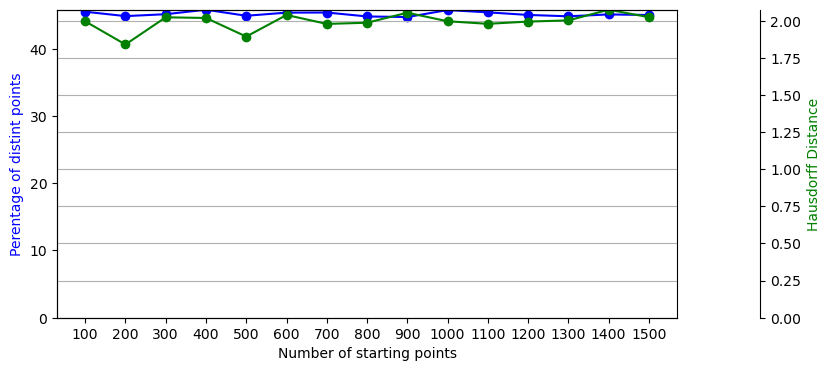

In [271]:
pdpbfgs, hdbfgs= get_values(folders)

In [272]:
for (p,h) in zip(pdpbfgs,hdbfgs):
    print(p, " * ", h)

45.5  *  1.9962297328220502
44.85  *  1.840358753585771
45.13333333333333  *  2.023433683247598
45.800000000000004  *  2.0189647876457766
44.9  *  1.893531116287871
45.36666666666667  *  2.039009274385175
45.385714285714286  *  1.979012117023116
44.800000000000004  *  1.9867701818707921
44.711111111111116  *  2.054353557974392
45.75  *  1.996774913706688
45.40909090909091  *  1.979522556919891
45.025  *  1.9946468683590277
44.82307692307692  *  2.0025749609452888
45.1  *  2.074503848407009
45.013333333333335  *  2.024435312499811


In [273]:
max(pdpbfgs), min(hdbfgs)

(45.800000000000004, 1.840358753585771)

In [274]:
#plot_solns(folders)

In [275]:
nubmer_points_list[np.argmax(pdpbfgs)]

400

### Histograms

In [276]:
# n_runs= 50 and 
n_points= nubmer_points_list[np.argmax(pdpbfgs)]
# Best
directory_path = "../Merit/solns_runs/Ex9/N_{}".format(n_points)
all_solnsbfgs= []

files= list_txt_files_in_directory(directory_path)
if len(files)>n_times:
    files= files[:n_times]
for file in files:
    if "._" in file:
        file= file.replace("._","")
    solns= np.genfromtxt(file, delimiter=',')

#     num, distinct_points = count_repeated_points(solns)
#     distinct_points= np.array(distinct_points)
    all_solnsbfgs.extend(solns.tolist())

all_solnsbfgs= np.array(all_solnsbfgs)
all_solnsbfgs= all_solnsbfgs.tolist()
#all_solnsbfgs = [point for point in all_solnsbfgs if point[0] >= 0 and point[1] >= 0]
all_solnsbfgs= np.array(all_solnsbfgs)

num, all_solnsbfgs = count_repeated_points(all_solnsbfgs)
all_solnsbfgs= np.array(all_solnsbfgs)

In [277]:
# plt.scatter(all_solnsbfgs[:,0], all_solnsbfgs[:,1], c= 'black')
# plt.xlim([0,1.0])
# plt.ylim([0,1.0])
# plt.grid(True)
# plt.show()

In [278]:
## x:
bins_list= [5, 10, 15, 20]
solns= all_solnsbfgs.copy()
x= solns[:,0]
x_min = np.min(x)
x_max = np.max(x)

## y:
y= solns[:,1]
y_min = np.min(y)
y_max = np.max(y)
# y

xbfgs= x.copy()
ybfgs= y.copy()

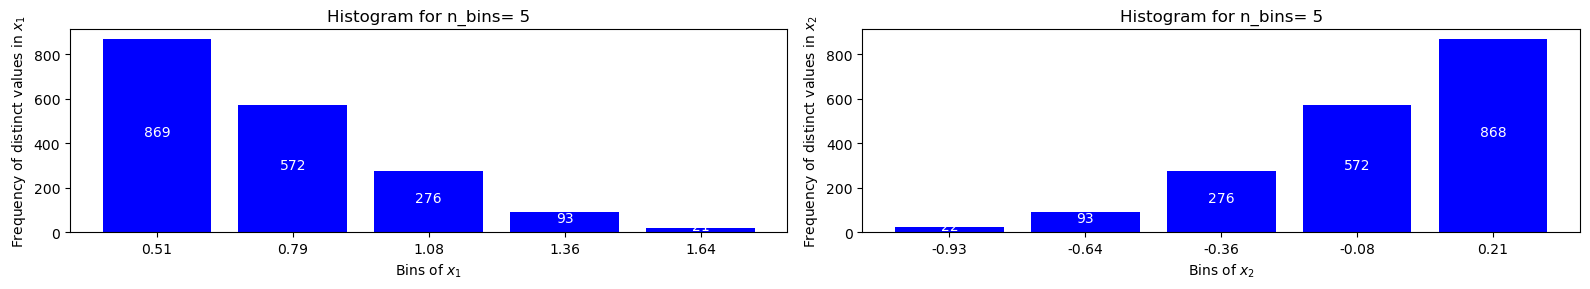

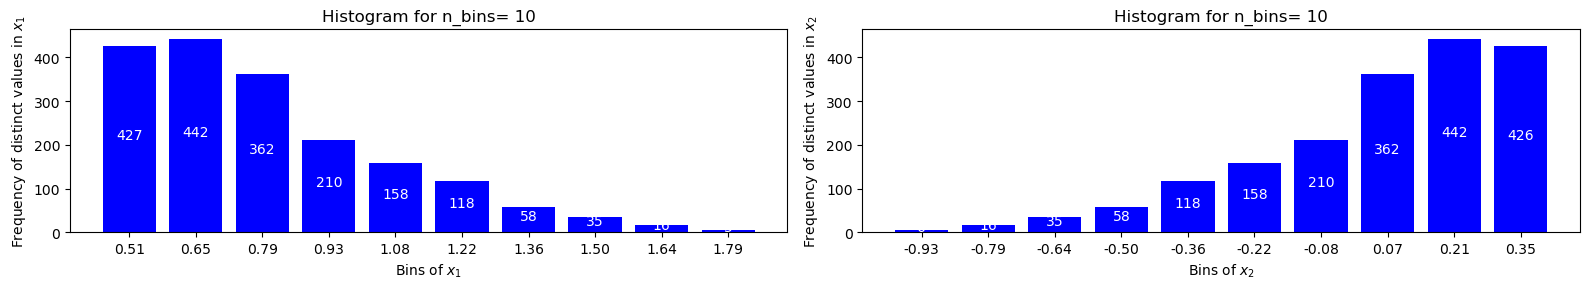

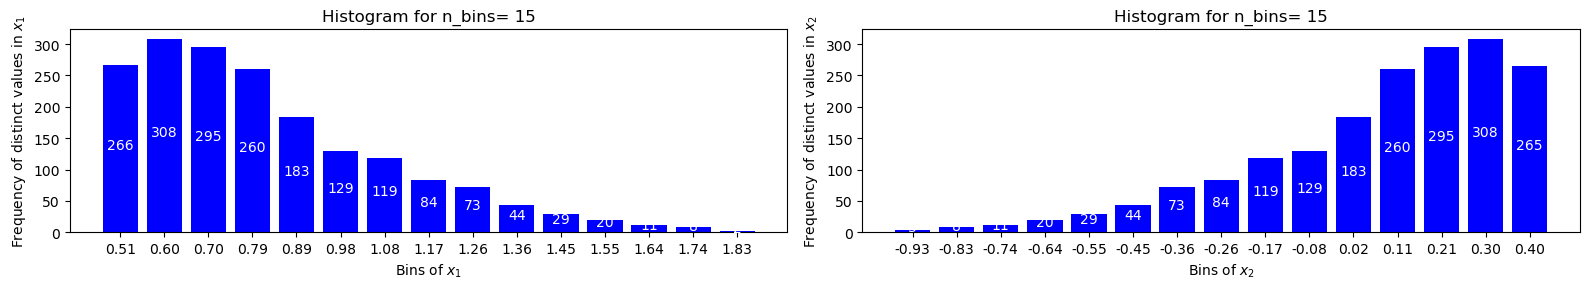

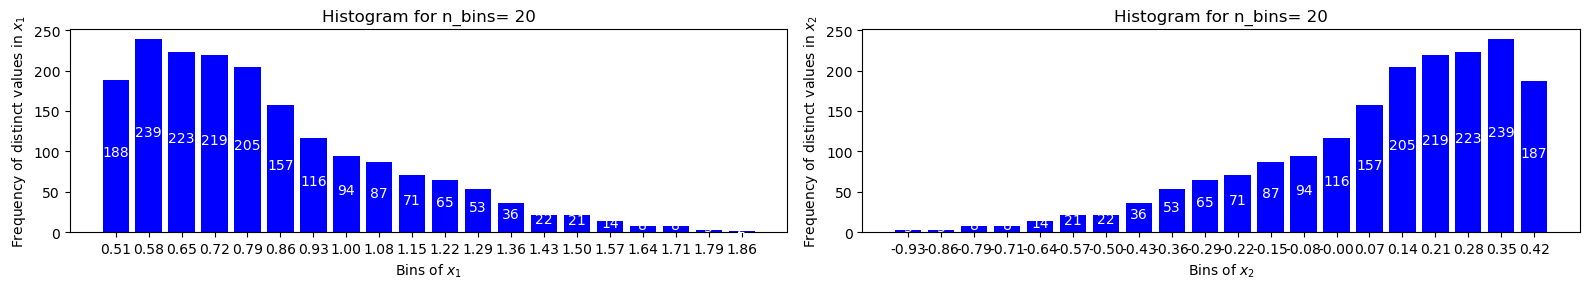

In [279]:
x_hist_bfgs= []
y_hist_bfgs= []
y_part_bfgs= []
x_part_bfgs= []
for n_bins in bins_list:
    partition_points = partition_interval(x_min, x_max, n_bins)
    x_part_bfgs.append(partition_points)
#     print("Partition points:", partition_points)
    bin_counts = count_values_in_bins(x, partition_points)
    x_hist_bfgs.append(bin_counts)
#     bin_counts= get_per(bin_counts)
#     print("Counts in each bin:", bin_counts)

    y_partition_points = partition_interval(y_min, y_max, n_bins)
    y_part_bfgs.append(y_partition_points)
    y_bin_counts = count_values_in_bins(y, y_partition_points)
    y_hist_bfgs.append(y_bin_counts)
    
#     y_bin_counts= get_per(y_bin_counts)
#     print("Counts in each bin:", y_bin_counts)


    plt.figure(figsize=(16, 3))

    plt.subplot(1, 2, 1)
    bars = plt.bar(range(len(bin_counts)), bin_counts.values(), align='center', color='blue')

    # Annotate each bar with its frequency value
    for i, bar in enumerate(bars):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() / 2, str(int(bin_counts[i])), ha='center', color='white')

    # Customize plot
    plt.xticks(range(len(bin_counts)), ["{:.2f}".format(b) for b in partition_points[:-1]])
    plt.xlabel('Bins of $x_1$')
    plt.ylabel('Frequency of distinct values in $x_1$')
    plt.title('Histogram for n_bins= {}'.format(len(bin_counts)))
#     plt.grid(True)

    plt.subplot(1, 2, 2)
    bars = plt.bar(range(len(y_bin_counts)), y_bin_counts.values(), align='center', color='blue')

    # Annotate each bar with its frequency value
    for i, bar in enumerate(bars):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() / 2, str(int(y_bin_counts[i])), ha='center', color='white')

    # Customize plot
    plt.xticks(range(len(y_bin_counts)), ["{:.2f}".format(b) for b in y_partition_points[:-1]])
    plt.xlabel('Bins of $x_2$')
    plt.ylabel('Frequency of distinct values in $x_2$')
    plt.title('Histogram for n_bins= {}'.format(len(y_bin_counts)))
#     plt.grid(True)
    plt.tight_layout()
    plt.savefig('../Merit/solns_runs/Ex9/'+'ex9_bfgs_hist'+str(n_bins)+'.png')
    plt.show()

### Uniform CDF vs. empirical CDF and KS-Test

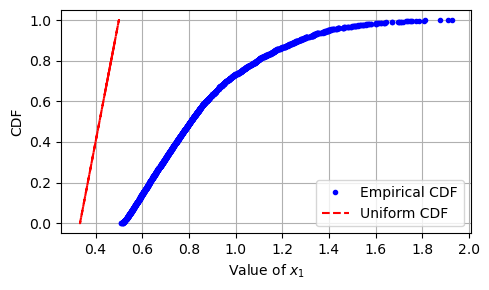

K-S Statistic: 0.514672885693065
P-Value: 0.0
Reject the null hypothesis: The sample does not follow the uniform distribution.


In [280]:
 # KS Test on x: 
a,b= end_point[0], start_point[0]
uniform_samples = np.random.uniform(low=a, high=b, size=len(x))
cdf_uniform= [get_cdf_of_uniform(i, a= a, b= b) for i in uniform_samples]

# Number of samples
n_samples = len(xbfgs)

# Generate uniform values in [0,1]
#uniform_samples = np.random.uniform(low=0.0, high=1.0, size=n_samples)

# Plotting the histogram of uniform samples
plt.figure(figsize=(5, 3))

# CDF Plot
sorted_samples = np.sort(xbfgs)
ecdf_bfgs_x = ECDF(xbfgs) #np.arange(1, n_samples+1) / n_samples
plt.plot(ecdf_bfgs_x.x, ecdf_bfgs_x.y, marker='.', linestyle='none', label='Empirical CDF',c= 'blue')
# plt.plot([0.5, 1], [0.0, 1], 'r--', label='Uniform CDF')
plt.plot(uniform_samples,cdf_uniform, 'r--', label='Uniform CDF')
# plt.title('CDF of Uniform Samples vs. Empiric')
plt.xlabel('Value of $x_1$')
plt.ylabel('CDF')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('../Merit/solns_runs/Ex9/ks_ex9_x1.png')
plt.show()

# Perform K-S test
ks_statistic, p_value = stats.kstest(xbfgs, "uniform")#stats.kstest(ecdf.y, stats.uniform.cdf) #stats.kstest(ecdf.y, cdf_uniform)

# Display the results
print(f"K-S Statistic: {ks_statistic}")
print(f"P-Value: {p_value}")

# Decision based on the p-value
alpha = 0.05
if p_value > alpha:
    print("Fail to reject the null hypothesis: The sample follows the uniform distribution.")
else:
    print("Reject the null hypothesis: The sample does not follow the uniform distribution.")

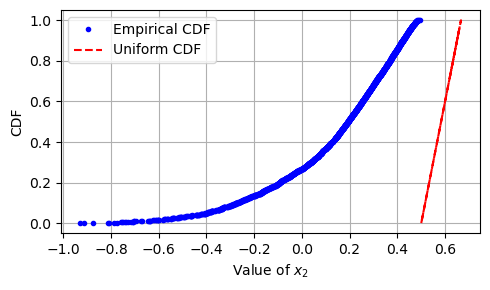

K-S Statistic: 0.5146728856930649
P-Value: 0.0
Reject the null hypothesis: The sample does not follow the uniform distribution.


In [281]:
# KS Test on y: 
# Number of samples
a,b= 1/2, 2/3

uniform_samples = np.random.uniform(low=a, high=b, size=len(x))
cdf_uniform= [get_cdf_of_uniform(i, a= a, b= b) for i in uniform_samples]

n_samples = len(ybfgs)
plt.figure(figsize=(5, 3))

# CDF Plot
sorted_samples = np.sort(ybfgs)
ecdf_bfgs_y = ECDF(ybfgs) # np.arange(1, n_samples+1) / n_samples
plt.plot(ecdf_bfgs_y.x, ecdf_bfgs_y.y, marker='.', linestyle='none', label='Empirical CDF', c= 'blue')
# plt.plot([1-1, 1-0.5], [1-1, 1], 'r--', label='Uniform CDF')
plt.plot(uniform_samples, cdf_uniform, 'r--', label='Uniform CDF')
# plt.title('CDF of Uniform Samples')
plt.xlabel('Value of $x_2$')
plt.ylabel('CDF')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('../Merit/solns_runs/Ex9/ks_ex9_x2.png')
plt.show()

# Perform K-S test
ks_statistic, p_value = stats.kstest(ybfgs, "uniform")

# Display the results
print(f"K-S Statistic: {ks_statistic}")
print(f"P-Value: {p_value}")

# Decision based on the p-value
alpha = 0.05
if p_value > alpha:
    print("Fail to reject the null hypothesis: The sample follows the uniform distribution.")
else:
    print("Reject the null hypothesis: The sample does not follow the uniform distribution.")

# EIA

## Number of starting points vs. PDP and HD

In [282]:
main_path = "../EIA/solns_runs/Ex9/"
subfolders = list_subfolders(main_path)

    
txt_files = list_subfolders(subfolders[0])
# list_txt_files(subfolders[0])

titles = [str(100*i) for i in range(1, 16)]

colors = [
    'blue', 'orange', 'r', 'yellow', 'purple',
    'brown', 'pink', 'gray', 'olive', 'cyan', 'red',
    'lightcoral', 'darkgoldenrod', 'mediumseagreen', 'green', 'mangeta'
]

folders= ["../EIA/solns_runs/Ex9/N_{}/".format(str(pt)) for pt in nubmer_points_list]
folders

['../EIA/solns_runs/Ex9/N_100/',
 '../EIA/solns_runs/Ex9/N_200/',
 '../EIA/solns_runs/Ex9/N_300/',
 '../EIA/solns_runs/Ex9/N_400/',
 '../EIA/solns_runs/Ex9/N_500/',
 '../EIA/solns_runs/Ex9/N_600/',
 '../EIA/solns_runs/Ex9/N_700/',
 '../EIA/solns_runs/Ex9/N_800/',
 '../EIA/solns_runs/Ex9/N_900/',
 '../EIA/solns_runs/Ex9/N_1000/',
 '../EIA/solns_runs/Ex9/N_1100/',
 '../EIA/solns_runs/Ex9/N_1200/',
 '../EIA/solns_runs/Ex9/N_1300/',
 '../EIA/solns_runs/Ex9/N_1400/',
 '../EIA/solns_runs/Ex9/N_1500/']

In [283]:
def get_values(folders):
    dist_= []
    avg_hd= []
    for pt in range(len(nubmer_points_list)):
        directory_path = folders[pt]

        files= list_txt_files_in_directory(directory_path)
        if len(files)>n_times:
            files= files[:n_times]
        res= []
        hd= []
        
        num_points= nubmer_points_list[pt]
        
        res_solns= []
        for file in files:
            
            if "._" in file:
                    file= file.replace("._","")
            
            solns= np.genfromtxt(file, delimiter=',')
            res_solns.extend(solns.tolist())
        
        
        res_solns= np.array(res_solns)
        num, distinct_points= count_repeated_points(res_solns)
        distinct_points= np.array(distinct_points)
        
        # Get PDP
        
        dist_.append((len(distinct_points)/(len(res_solns)))*100)
        
        # Get HD:
        
        points0 = [((3-t)/6, (3+t)/6) for t in np.linspace(0, 1, int(len(distinct_points)/3))]
        points = points0
        points= [(0.0,0.0)]+points
        points = np.array(points)

        

        print(len(distinct_points),len(res_solns))
        hausdorff_distance = directed_hausdorff(distinct_points, points)[0]
        avg_hd.append(hausdorff_distance)
        
    # Create subplots with different scales
    fig, ax1 = plt.subplots(figsize=(8, 4))

    # Create second axis with different scale
    ax1.set_xlabel('Number of starting points')
#     ax2 = ax1.twinx()
    ax1.set_ylim([0.0, np.max(dist_)])
    ax1.plot(nubmer_points_list, dist_, 'bo-')
    
#     ax1.set_yticks(dist_)
    
    ax1.set_ylabel('Perentage of distint points',color='blue')
#     ax1.set_ylabel('Perentage of distint points', color='b')


    # Create third axis with different scale
    ax2 = ax1.twinx()
    ax2.spines['right'].set_position(('outward', 60))  # Move the spine to the right
    ax2.plot(nubmer_points_list, avg_hd, 'go-')
    ax2.set_ylabel('Hausdorff Distance', color='g')
    ax2.set_ylim([0.0, np.max(avg_hd)])

    xticks = nubmer_points_list  # Precisely specify xticks from 0 to 10 with a step of 1
    ax1.set_xticks(xticks)
    ax1.set_xticklabels([f'{tick:.0f}' for tick in xticks])  # Format labels as strings with one decimal place


#     plt.savefig('./plots/Metrics/Ex1/ex1_gsm.jpeg')
    plt.savefig('../EIA/solns_runs/Ex9/plot_ex9.png')
# plt.xticks(list(range(len(possible_num_points))),possible_num_points)
    plt.grid(True)
    plt.show()

        
    return dist_,avg_hd

451 1000
1026 2000
1581 3000
2108 4000
2673 5000
3229 6000
3822 7000
4414 8000
4983 9000
5585 10000
6119 11000
6681 12000
7251 13000
7826 14000
8431 15000


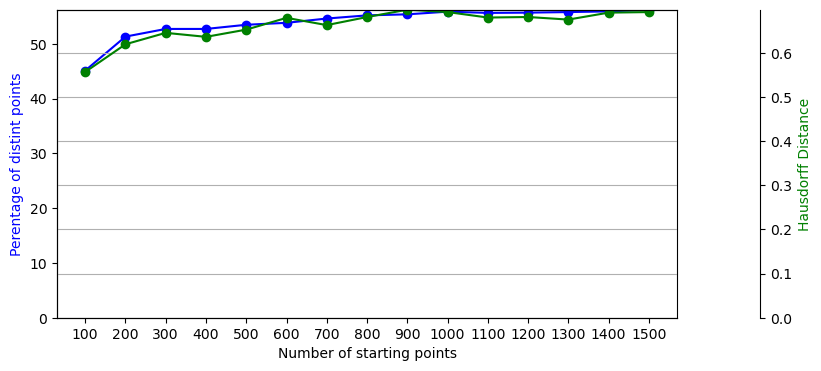

In [284]:
pdpeia, hdeia= get_values(folders)

In [285]:
for (p,h) in zip(pdpeia,hdeia):
    print(p, " * ", h)

45.1  *  0.5565444406564279
51.300000000000004  *  0.6192297822770386
52.7  *  0.6450791985229439
52.7  *  0.636006185897933
53.459999999999994  *  0.6524041133566919
53.81666666666667  *  0.6790411583226941
54.6  *  0.6626080354113111
55.175  *  0.6808895931392172
55.36666666666667  *  0.6974513585698892
55.85  *  0.6921684746326551
55.627272727272725  *  0.6797585286623868
55.675  *  0.6809471581360685
55.77692307692308  *  0.6751331193584307
55.900000000000006  *  0.6908566525709192
56.20666666666667  *  0.6921232889324271


In [286]:
max(pdpeia), min(hdeia)

(56.20666666666667, 0.5565444406564279)

In [287]:
len(pdpeia)

15

In [288]:
nubmer_points_list[np.argmax(pdpeia)]

1500

### Histograms

In [289]:
# n_runs= 50 and 
n_points= nubmer_points_list[np.argmax(pdpeia)]
# Best
directory_path = "../EIA/solns_runs/Ex9/N_{}".format(n_points)
all_solnseia= []

files= list_txt_files_in_directory(directory_path)
if len(files)>n_times:
    files= files[:n_times]
for file in files:
    if "._" in file:
        file= file.replace("._","")
    solns= np.genfromtxt(file, delimiter=',')

#     num, distinct_points = count_repeated_points(solns)
#     distinct_points= np.array(distinct_points)
    all_solnseia.extend(solns.tolist())

all_solnseia= np.array(all_solnseia)
_,all_solnseia= count_repeated_points(all_solnseia)
all_solnseia= np.array(all_solnseia)

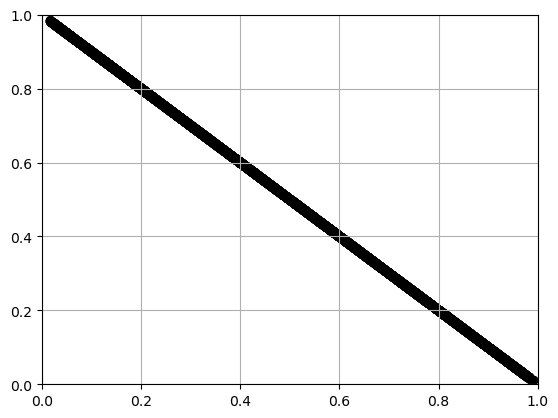

In [290]:
plt.scatter(all_solnseia[:,0], all_solnseia[:,1], c= 'black')
plt.xlim([0,1.0])
plt.ylim([0,1.0])
plt.grid(True)
plt.show()

In [291]:
bins_list= [5, 10, 15, 20]
solns= all_solnseia.copy()
x= solns[:,0]
x_min = np.min(x)
x_max = np.max(x)

## y:
y= solns[:,1]
y_min = np.min(y)
y_max = np.max(y)
# y

# y

xeia= x.copy()
yeia= y.copy()

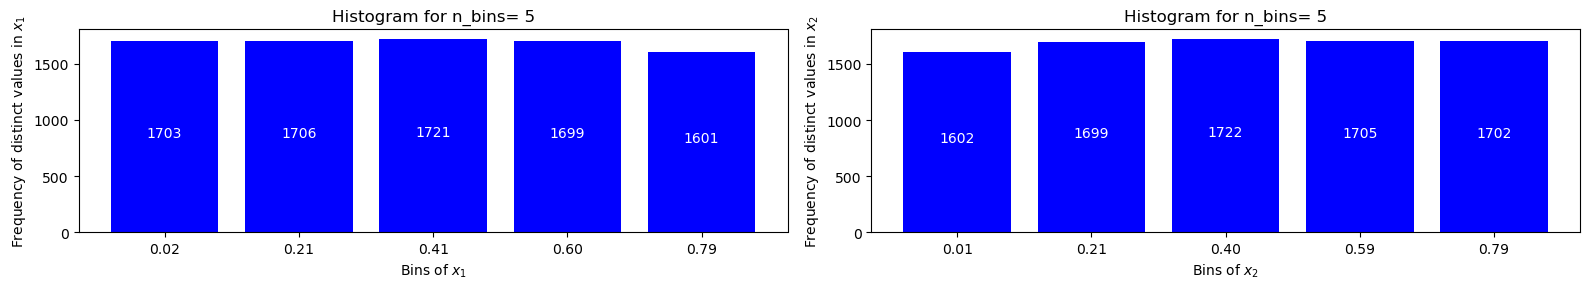

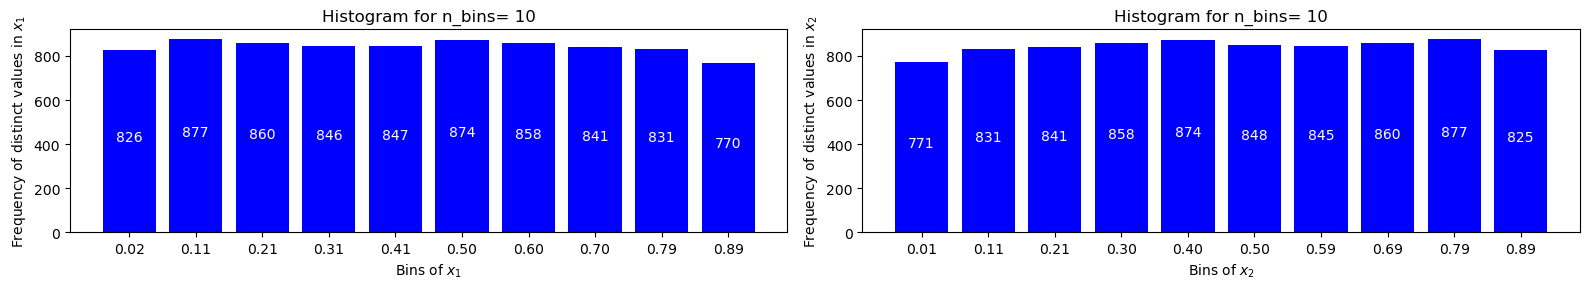

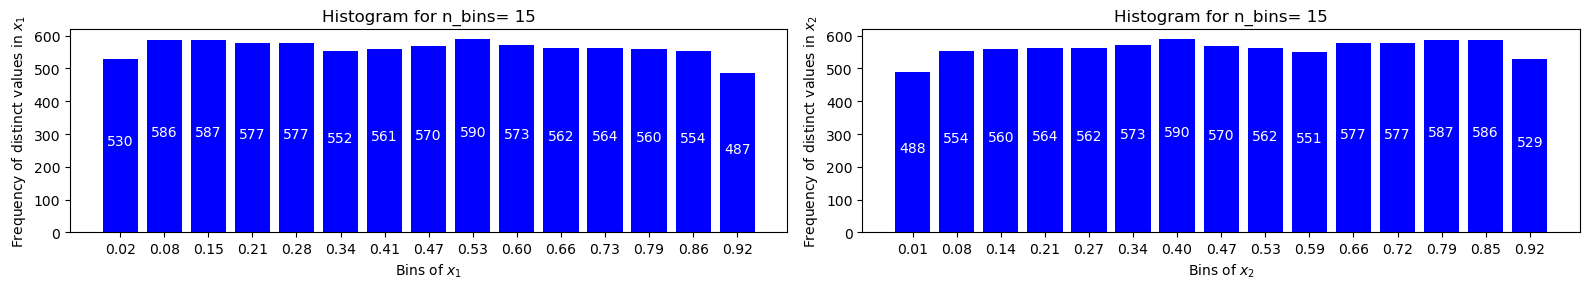

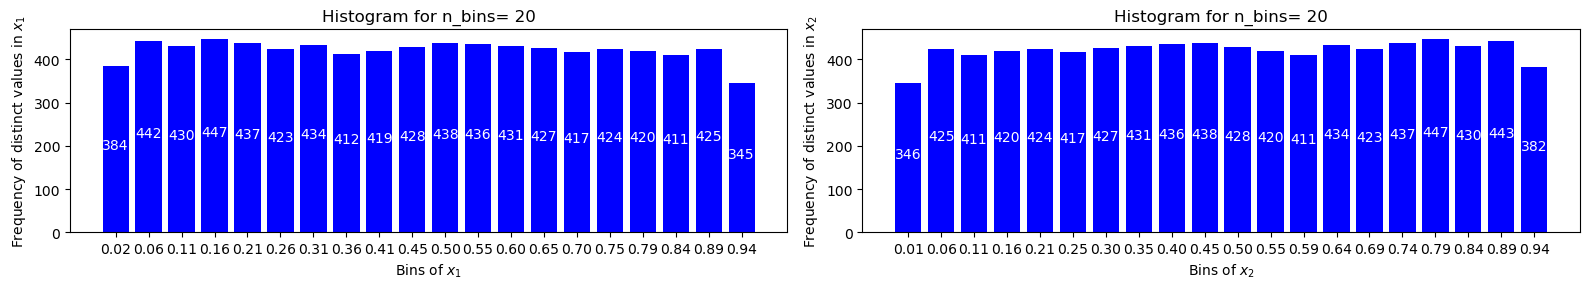

In [292]:
x_hist_eia= []
y_hist_eia= []
y_part_eia= []
x_part_eia= []
for n_bins in bins_list:
    partition_points = partition_interval(x_min, x_max, n_bins)
    x_part_eia.append(partition_points)
#     print("Partition points:", partition_points)
    bin_counts = count_values_in_bins(x, partition_points)
    x_hist_eia.append(bin_counts)
#     bin_counts= get_per(bin_counts)
#     print("Counts in each bin:", bin_counts)

    y_partition_points = partition_interval(y_min, y_max, n_bins)
    y_part_eia.append(y_partition_points)
    y_bin_counts = count_values_in_bins(y, y_partition_points)
    y_hist_eia.append(y_bin_counts)
    
#     y_bin_counts= get_per(y_bin_counts)
#     print("Counts in each bin:", y_bin_counts)


    plt.figure(figsize=(16, 3))

    plt.subplot(1, 2, 1)
    bars = plt.bar(range(len(bin_counts)), bin_counts.values(), align='center', color='blue')

    # Annotate each bar with its frequency value
    for i, bar in enumerate(bars):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() / 2, str(int(bin_counts[i])), ha='center', color='white')

    # Customize plot
    plt.xticks(range(len(bin_counts)), ["{:.2f}".format(b) for b in partition_points[:-1]])
    plt.xlabel('Bins of $x_1$')
    plt.ylabel('Frequency of distinct values in $x_1$')
    plt.title('Histogram for n_bins= {}'.format(len(bin_counts)))
#     plt.grid(True)

    plt.subplot(1, 2, 2)
    bars = plt.bar(range(len(y_bin_counts)), y_bin_counts.values(), align='center', color='blue')

    # Annotate each bar with its frequency value
    for i, bar in enumerate(bars):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() / 2, str(int(y_bin_counts[i])), ha='center', color='white')

    # Customize plot
    plt.xticks(range(len(y_bin_counts)), ["{:.2f}".format(b) for b in y_partition_points[:-1]])
    plt.xlabel('Bins of $x_2$')
    plt.ylabel('Frequency of distinct values in $x_2$')
    plt.title('Histogram for n_bins= {}'.format(len(y_bin_counts)))
#     plt.grid(True)
    plt.tight_layout()
    plt.savefig('../EIA/solns_runs/Ex9/'+'ex9_eia_hist'+str(n_bins)+'.png')
    plt.show()

### Uniform CDF vs. empirical CDF and  KS-Test

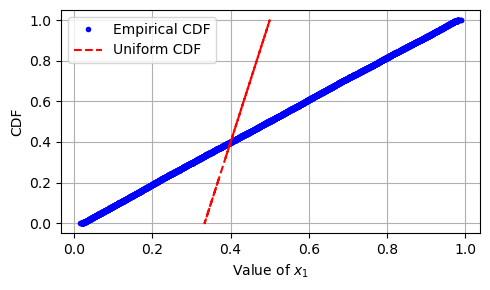

K-S Statistic: 0.02121317055725104
P-Value: 0.0009983245121443992
Reject the null hypothesis: The sample does not follow the uniform distribution.


In [293]:
# KS Test on x: 
a,b= end_point[0], start_point[0]
uniform_samples = np.random.uniform(low=a, high=b, size=len(xeia))
cdf_uniform= [get_cdf_of_uniform(i, a= a, b= b) for i in uniform_samples]

# Number of samples
n_samples = len(xeia)

# Generate uniform values in [0,1]
#uniform_samples = np.random.uniform(low=0.0, high=1.0, size=n_samples)

# Plotting the histogram of uniform samples
plt.figure(figsize=(5, 3))

# CDF Plot
sorted_samples = np.sort(xeia)
ecdf_eia_x = ECDF(xeia) #np.arange(1, n_samples+1) / n_samples
plt.plot(ecdf_eia_x.x, ecdf_eia_x.y, marker='.', linestyle='none', label='Empirical CDF',c= 'blue')
# plt.plot([0.5, 1], [0.0, 1], 'r--', label='Uniform CDF')
plt.plot(uniform_samples,cdf_uniform, 'r--', label='Uniform CDF')
# plt.title('CDF of Uniform Samples vs. Empiric')
plt.xlabel('Value of $x_1$')
plt.ylabel('CDF')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('../EIA/solns_runs/Ex8/ks_ex8_x1.png')
plt.show()

# Perform K-S test
ks_statistic, p_value = stats.kstest(xeia, "uniform")#stats.kstest(ecdf.y, stats.uniform.cdf) #stats.kstest(ecdf.y, cdf_uniform)

# Display the results
print(f"K-S Statistic: {ks_statistic}")
print(f"P-Value: {p_value}")

# Decision based on the p-value
alpha = 0.05
if p_value > alpha:
    print("Fail to reject the null hypothesis: The sample follows the uniform distribution.")
else:
    print("Reject the null hypothesis: The sample does not follow the uniform distribution.") 

In [294]:
ks_statistic,p_value

(0.02121317055725104, 0.0009983245121443992)

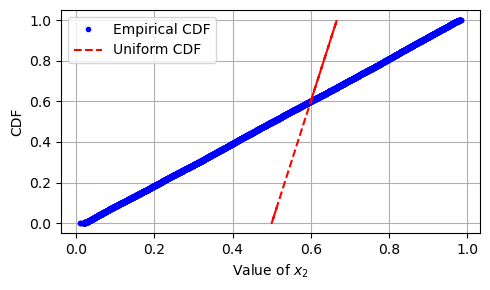

K-S Statistic: 0.021215617200850856
P-Value: 0.0009965766316539977
Reject the null hypothesis: The sample does not follow the uniform distribution.


In [295]:
# KS Test on y: 
# Number of samples
a,b= 1/2, 2/3
uniform_samples = np.random.uniform(low=a, high=b, size=len(xeia))
cdf_uniform= [get_cdf_of_uniform(i, a= a, b= b) for i in uniform_samples]

n_samples = len(yeia)
plt.figure(figsize=(5, 3))

# CDF Plot
sorted_samples = np.sort(yeia)
ecdf_eia_y = ECDF(yeia) # np.arange(1, n_samples+1) / n_samples
plt.plot(ecdf_eia_y.x, ecdf_eia_y.y, marker='.', linestyle='none', label='Empirical CDF', c= 'blue')
# plt.plot([1-1, 1-0.5], [1-1, 1], 'r--', label='Uniform CDF')
plt.plot(uniform_samples, cdf_uniform, 'r--', label='Uniform CDF')
# plt.title('CDF of Uniform Samples')
plt.xlabel('Value of $x_2$')
plt.ylabel('CDF')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('../EIA/solns_runs/Ex8/ks_ex8_x2.png')
plt.show()

# Perform K-S test
ks_statistic, p_value = stats.kstest(yeia, "uniform")

# Display the results
print(f"K-S Statistic: {ks_statistic}")
print(f"P-Value: {p_value}")

# Decision based on the p-value
alpha = 0.05
if p_value > alpha:
    print("Fail to reject the null hypothesis: The sample follows the uniform distribution.")
else:
    print("Reject the null hypothesis: The sample does not follow the uniform distribution.")

# SGD (one run with 100 points)

In [296]:
main_path = "../SGD/solns_runs/Ex9/"
subfolders = list_subfolders(main_path)

    
txt_files = list_subfolders(subfolders[0])
# list_txt_files(subfolders[0])

titles = [str(100*i) for i in range(1, 16)]

colors = [
    'blue', 'orange', 'r', 'yellow', 'purple',
    'brown', 'pink', 'gray', 'olive', 'cyan', 'red',
    'lightcoral', 'darkgoldenrod', 'mediumseagreen', 'green', 'mangeta'
]

folders= ["../SGD/solns_runs/Ex9/N_{}/".format(str(pt)) for pt in nubmer_points_list]
folders

['../SGD/solns_runs/Ex9/N_100/',
 '../SGD/solns_runs/Ex9/N_200/',
 '../SGD/solns_runs/Ex9/N_300/',
 '../SGD/solns_runs/Ex9/N_400/',
 '../SGD/solns_runs/Ex9/N_500/',
 '../SGD/solns_runs/Ex9/N_600/',
 '../SGD/solns_runs/Ex9/N_700/',
 '../SGD/solns_runs/Ex9/N_800/',
 '../SGD/solns_runs/Ex9/N_900/',
 '../SGD/solns_runs/Ex9/N_1000/',
 '../SGD/solns_runs/Ex9/N_1100/',
 '../SGD/solns_runs/Ex9/N_1200/',
 '../SGD/solns_runs/Ex9/N_1300/',
 '../SGD/solns_runs/Ex9/N_1400/',
 '../SGD/solns_runs/Ex9/N_1500/']

In [297]:
def get_values(folders):
    dist_= []
    avg_hd= []
    for pt in range(len(nubmer_points_list)):
        directory_path = folders[pt]

        files= list_txt_files_in_directory(directory_path)
        if len(files)>n_times:
            files= files[:n_times]
        res= []
        hd= []
        
        num_points= nubmer_points_list[pt]
        
        res_solns= []
        for file in files:
            
            if "._" in file:
                    file= file.replace("._","")
            
            solns= np.genfromtxt(file, delimiter=',')[:,:-1]
            #mask= solns[:,-1]<=2.5
            #solns= solns[mask][:,:-1]
            res_solns.extend(solns.tolist())
        
        
        res_solns= np.array(res_solns)
        num, distinct_points= count_repeated_points(res_solns)
        distinct_points= np.array(distinct_points)
        
        # Get PDP
        
        dist_.append((len(distinct_points)/(len(res_solns)))*100)
        
        # Get HD:
        
        points0 = [((3-t)/6, (3+t)/6) for t in np.linspace(0, 1, int(len(distinct_points)/3))]
        points = points0
        points= [(0.0,0.0)]+points
        points = np.array(points)

        

        print(len(distinct_points),len(res_solns))
        hausdorff_distance = directed_hausdorff(distinct_points, points)[0]
        avg_hd.append(hausdorff_distance)
        
    # Create subplots with different scales
    fig, ax1 = plt.subplots(figsize=(8, 4))

    # Create second axis with different scale
    ax1.set_xlabel('Number of starting points')
#     ax2 = ax1.twinx()
    ax1.set_ylim([0.0, np.max(dist_)])
    ax1.plot(nubmer_points_list, dist_, 'bo-')
    
#     ax1.set_yticks(dist_)
    
    ax1.set_ylabel('Perentage of distint points',color='blue')
#     ax1.set_ylabel('Perentage of distint points', color='b')


    # Create third axis with different scale
    ax2 = ax1.twinx()
    ax2.spines['right'].set_position(('outward', 60))  # Move the spine to the right
    ax2.plot(nubmer_points_list, avg_hd, 'go-')
    ax2.set_ylabel('Hausdorff Distance', color='g')
    ax2.set_ylim([0.0, np.max(avg_hd)])

    xticks = nubmer_points_list  # Precisely specify xticks from 0 to 10 with a step of 1
    ax1.set_xticks(xticks)
    ax1.set_xticklabels([f'{tick:.0f}' for tick in xticks])  # Format labels as strings with one decimal place


#     plt.savefig('./plots/Metrics/Ex1/ex1_gsm.jpeg')
    plt.savefig('../SGD/solns_runs/Ex9/plot_ex9.png')
# plt.xticks(list(range(len(possible_num_points))),possible_num_points)
    plt.grid(True)
    plt.show()

        
    return dist_,avg_hd

512 1000
1087 2000
1770 3000
2570 4000
3383 5000
4253 6000
5098 7000
6081 8000
7042 9000
7867 10000
8824 11000
9819 12000
10718 13000
11663 14000
12656 15000


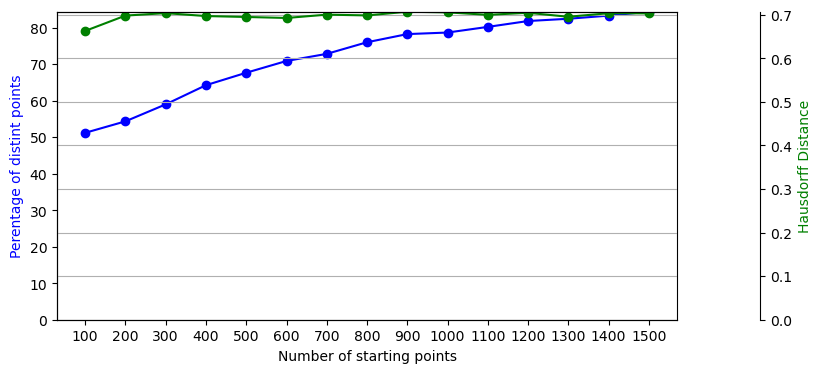

In [298]:
pdpsgd, hdsgd= get_values(folders)

In [299]:
for (p,h) in zip(pdpsgd,hdsgd):
    print(p, " * ", h)

51.2  *  0.6627949569700013
54.35  *  0.6979874731869692
59.0  *  0.7036290996187904
64.25  *  0.696903369409315
67.66  *  0.6947953142874416
70.88333333333333  *  0.6925123988236255
72.82857142857144  *  0.7001458468475035
76.0125  *  0.6983669131851391
78.24444444444445  *  0.7068463686554558
78.67  *  0.705348494330979
80.21818181818182  *  0.6997304015663441
81.825  *  0.704379324013775
82.44615384615385  *  0.695261910108045
83.30714285714286  *  0.7034186931560691
84.37333333333333  *  0.7029992168376737


## Histograms

In [300]:
nubmer_points_list[np.argmax(pdpsgd)]

1500

In [301]:
n_points= nubmer_points_list[np.argmax(pdpsgd)]
# Best
directory_path = "../SGD/solns_runs/Ex9/N_{}".format(n_points)
all_solnssgd= []

files= list_txt_files_in_directory(directory_path)
if len(files)>n_times:
    files= files[:n_times]
for file in files:
    if "._" in file:
        file= file.replace("._","")
    solns= np.genfromtxt(file, delimiter=',')[:,:-1]
    #mask= solns[:,-1]<2.5
    #solns= solns[mask]
#     num, distinct_points = count_repeated_points(solns)
#     distinct_points= np.array(distinct_points)
    
    all_solnssgd.extend(solns.tolist())


all_solnssgd= np.array(all_solnssgd)

num, all_solnssgd = count_repeated_points(all_solnssgd)
all_solnssgd= np.array(all_solnssgd)
all_solnssgd

array([[0.47110339, 0.76432113],
       [0.67789404, 0.64363648],
       [0.6805264 , 0.63834629],
       ...,
       [0.44862933, 0.77564798],
       [0.65094767, 0.67397041],
       [0.15147673, 0.92437547]])

In [302]:
all_solnssgd.shape

(12656, 2)

In [303]:
# plt.scatter(all_solnssgd[:,0], all_solnssgd[:,1], c= 'black')
# plt.xlim([0,1.0])
# plt.ylim([0,1.0])
# plt.grid(True)
# plt.show()

In [304]:
len(all_solnssgd)

12656

In [305]:
## x:
bins_list= [5, 10, 15, 20]
solns= all_solnssgd.copy()
x= solns[:,0]
x_min = np.min(x)
x_max = np.max(x)

## y:
y= solns[:,1]
y_min = np.min(y)
y_max = np.max(y)
# y

xsgd= x.copy()
ysgd= y.copy()

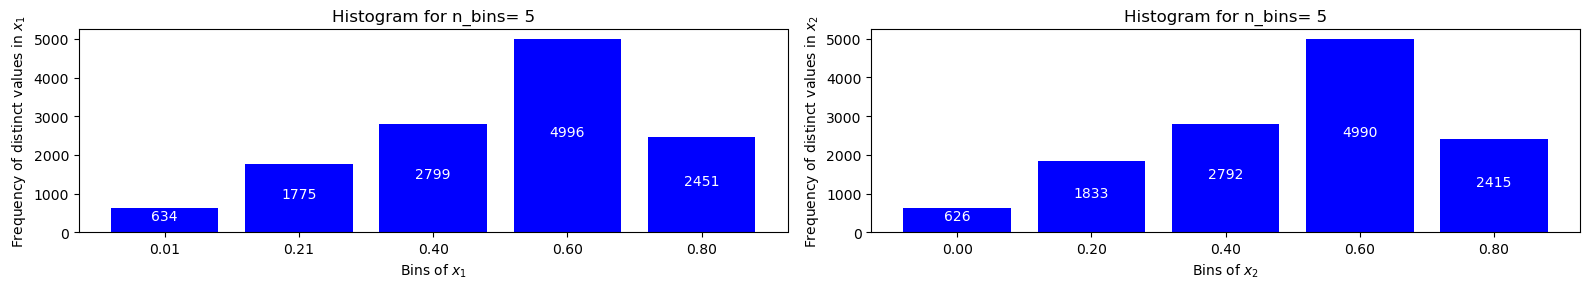

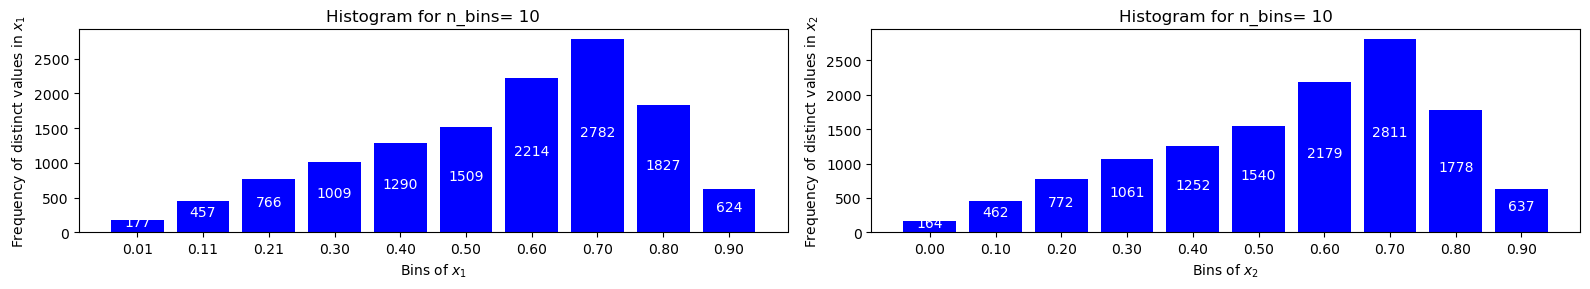

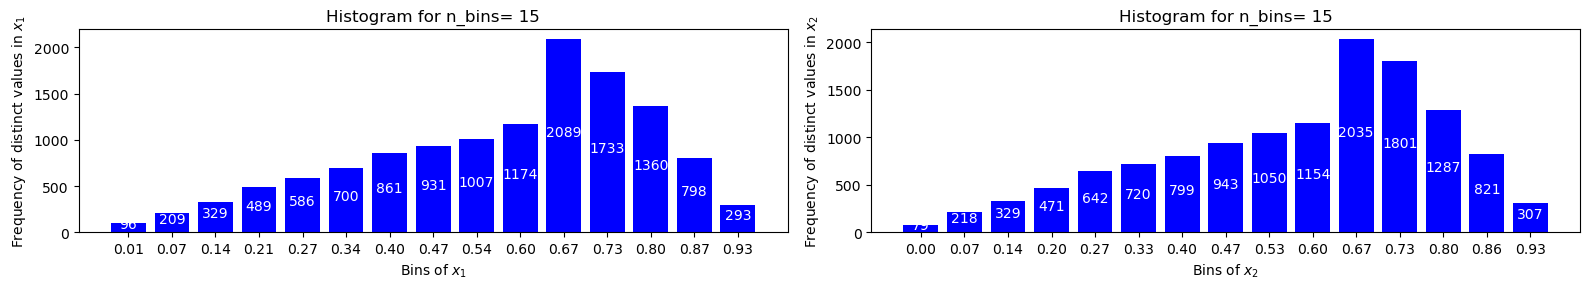

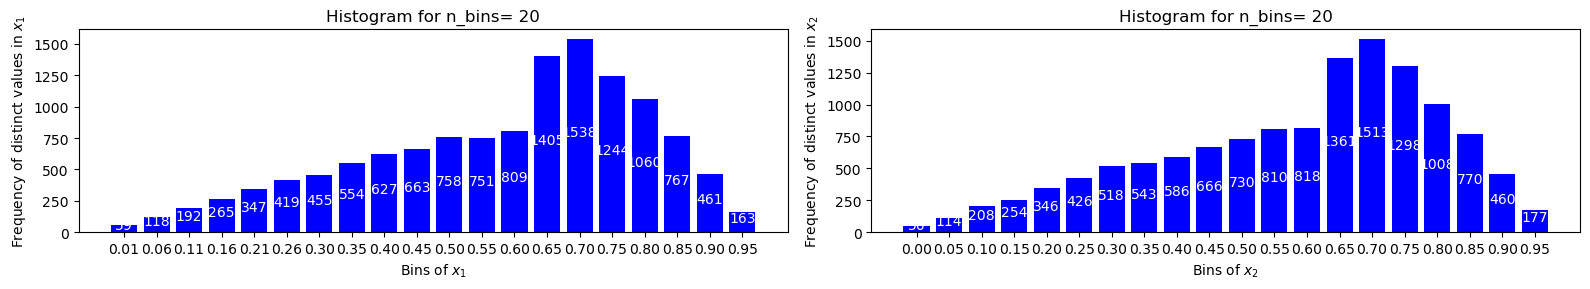

In [306]:
x_hist_sgd= []
y_hist_sgd= []
y_part_sgd= []
x_part_sgd= []
for n_bins in bins_list:
    partition_points = partition_interval(x_min, x_max, n_bins)
    x_part_sgd.append(partition_points)
#     print("Partition points:", partition_points)
    bin_counts = count_values_in_bins(x, partition_points)
    x_hist_sgd.append(bin_counts)
#     bin_counts= get_per(bin_counts)
#     print("Counts in each bin:", bin_counts)

    y_partition_points = partition_interval(y_min, y_max, n_bins)
    y_part_sgd.append(y_partition_points)
    y_bin_counts = count_values_in_bins(y, y_partition_points)
    y_hist_sgd.append(y_bin_counts)
    
#     y_bin_counts= get_per(y_bin_counts)
#     print("Counts in each bin:", y_bin_counts)


    plt.figure(figsize=(16, 3))

    plt.subplot(1, 2, 1)
    bars = plt.bar(range(len(bin_counts)), bin_counts.values(), align='center', color='blue')

    # Annotate each bar with its frequency value
    for i, bar in enumerate(bars):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() / 2, str(int(bin_counts[i])), ha='center', color='white')

    # Customize plot
    plt.xticks(range(len(bin_counts)), ["{:.2f}".format(b) for b in partition_points[:-1]])
    plt.xlabel('Bins of $x_1$')
    plt.ylabel('Frequency of distinct values in $x_1$')
    plt.title('Histogram for n_bins= {}'.format(len(bin_counts)))
#     plt.grid(True)

    plt.subplot(1, 2, 2)
    bars = plt.bar(range(len(y_bin_counts)), y_bin_counts.values(), align='center', color='blue')

    # Annotate each bar with its frequency value
    for i, bar in enumerate(bars):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() / 2, str(int(y_bin_counts[i])), ha='center', color='white')

    # Customize plot
    plt.xticks(range(len(y_bin_counts)), ["{:.2f}".format(b) for b in y_partition_points[:-1]])
    plt.xlabel('Bins of $x_2$')
    plt.ylabel('Frequency of distinct values in $x_2$')
    plt.title('Histogram for n_bins= {}'.format(len(y_bin_counts)))
#     plt.grid(True)
    plt.tight_layout()
    plt.savefig('../SGD/solns_runs/Ex9/'+'ex9_sgd_hist'+str(n_bins)+'.png')
    plt.show()

## Uniform CDF vs. empirical CDF and KS-Test

## K-S Test

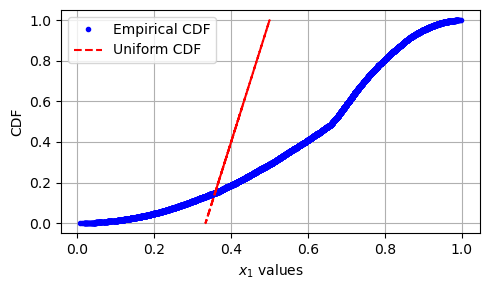

K-S Statistic: 0.2147722115726148
P-Value: 0.0
Reject the null hypothesis: The sample does not follow the uniform distribution.


In [307]:
# KS Test on x: 
a,b= end_point[0], start_point[0]
uniform_samples = np.random.uniform(low=a, high=b, size=len(xsgd))
cdf_uniform= [get_cdf_of_uniform(i, a= a, b= b) for i in uniform_samples]

# Number of samples
n_samples = len(xsgd)

# Generate uniform values in [0,1]
#uniform_samples = np.random.uniform(low=0.0, high=1.0, size=n_samples)

# Plotting the histogram of uniform samples
plt.figure(figsize=(5, 3))

# CDF Plot
sorted_samples = np.sort(xsgd)
ecdf_sgd_x = ECDF(xsgd) #np.arange(1, n_samples+1) / n_samples
plt.plot(ecdf_sgd_x.x, ecdf_sgd_x.y, marker='.', linestyle='none', label='Empirical CDF',c= 'blue')
# plt.plot([0.5, 1], [0.0, 1], 'r--', label='Uniform CDF')
plt.plot(uniform_samples,cdf_uniform, 'r--', label='Uniform CDF')
# plt.title('CDF of Uniform Samples vs. Empiric')
plt.xlabel('$x_1$ values')
plt.ylabel('CDF')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('../SGD/solns_runs/Ex9/ks_ex9x1.png')
plt.show()

# Perform K-S test
ks_statistic, p_value = stats.kstest(xsgd, "uniform")#stats.kstest(ecdf.y, stats.uniform.cdf) #stats.kstest(ecdf.y, cdf_uniform)

# Display the results
print(f"K-S Statistic: {ks_statistic}")
print(f"P-Value: {p_value}")

# Decision based on the p-value
alpha = 0.05
if p_value > alpha:
    print("Fail to reject the null hypothesis: The sample follows the uniform distribution.")
else:
    print("Reject the null hypothesis: The sample does not follow the uniform distribution.") 

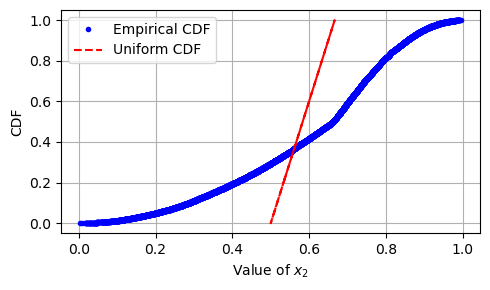

K-S Statistic: 0.2104290171222804
P-Value: 0.0
Reject the null hypothesis: The sample does not follow the uniform distribution.


In [308]:
# KS Test on y: 
# Number of samples
a,b= 1/2, 2/3
uniform_samples = np.random.uniform(low=a, high=b, size=len(ysgd))
cdf_uniform= [get_cdf_of_uniform(i, a= a, b= b) for i in uniform_samples]

n_samples = len(ysgd)
plt.figure(figsize=(5, 3))

# CDF Plot
sorted_samples = np.sort(ysgd)
ecdf_sgd_y = ECDF(ysgd) # np.arange(1, n_samples+1) / n_samples
plt.plot(ecdf_sgd_y.x, ecdf_sgd_y.y, marker='.', linestyle='none', label='Empirical CDF', c= 'blue')
# plt.plot([1-1, 1-0.5], [1-1, 1], 'r--', label='Uniform CDF')
plt.plot(uniform_samples, cdf_uniform, 'r--', label='Uniform CDF')
# plt.title('CDF of Uniform Samples')
plt.xlabel('Value of $x_2$')
plt.ylabel('CDF')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('../SGD/solns_runs/Ex9/ks_ex9_x2.png')
plt.show()

# Perform K-S test
ks_statistic, p_value = stats.kstest(ysgd, "uniform")

# Display the results
print(f"K-S Statistic: {ks_statistic}")
print(f"P-Value: {p_value}")

# Decision based on the p-value
alpha = 0.05
if p_value > alpha:
    print("Fail to reject the null hypothesis: The sample follows the uniform distribution.")
else:
    print("Reject the null hypothesis: The sample does not follow the uniform distribution.")

# KS-Overall

In [309]:
def KS_test(sample, a, b, alpha=0.05):
    ecdf_sgd_x = ECDF(sample)
    x1 = ecdf_sgd_x.x       # First coordinate
    # ecdf_sgd_y = ECDF(ysgd)
    # x2 = ecdf_sgd_y.x   # Second coordinate
    # print("Algorithm ", name)
    ks_statistic, p_value = stats.kstest(sample, "uniform", args=(a, b-a))
    print(f"K-S Statistic: {ks_statistic:.4f}")
    print(f"P-Value: {p_value:.4f}")
    if p_value > alpha:
        print(f"Result: Fail to reject H0 → Sample follows Uniform({a},{b})\n")
    else:
        print(f"Result: Reject H0 → Sample does NOT follow Uniform({a},{b})\n")

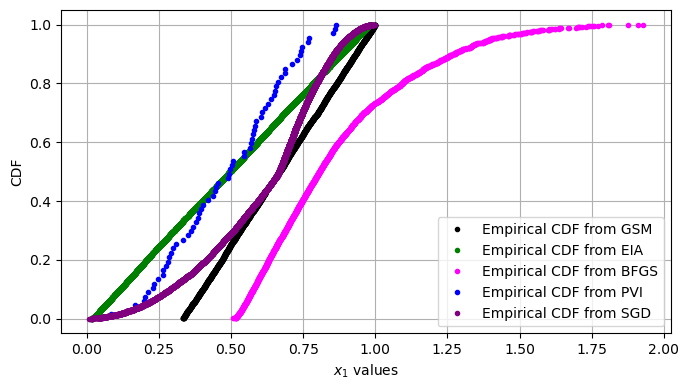

GSM
K-S Statistic: 0.0050
P-Value: 1.0000
Result: Fail to reject H0 → Sample follows Uniform(0.3335552528688438,0.9997697517017792)

*********
EIA
K-S Statistic: 0.0118
P-Value: 0.1931
Result: Fail to reject H0 → Sample follows Uniform(0.01560517167226122,0.9894104652182873)

*********
BFGS
K-S Statistic: 0.3909
P-Value: 0.0000
Result: Reject H0 → Sample does NOT follow Uniform(0.5071030782880976,1.927623730520187)

*********
PVI
K-S Statistic: 0.1019
P-Value: 0.4593
Result: Fail to reject H0 → Sample follows Uniform(0.08373946886247041,0.8631597407559793)

*********
SGD
K-S Statistic: 0.2111
P-Value: 0.0000
Result: Reject H0 → Sample does NOT follow Uniform(0.007908288522446849,0.998071994670366)

*********


In [310]:
# KS Test on x: 
a,b= end_point[0], start_point[0]
uniform_samples = np.random.uniform(low=a, high=b, size=len(x))
#uniform_samples= np.hstack((uniform_samples,5))
cdf_uniform= [get_cdf_of_uniform(i, a= a, b= b) for i in uniform_samples]

# Number of samples
n_samples = len(x)

# Generate uniform values in [0,1]
#uniform_samples = np.random.uniform(low=0.0, high=1.0, size=n_samples)

# Plotting the histogram of uniform samples
plt.figure(figsize=(7, 4))

# CDF Plot
sorted_samples = np.sort(x)
ecdfgsm= ECDF(xgsm) #np.arange(1, n_samples+1) / n_samples
ecdfeia= ECDF(xeia) #np.arange(1, n_samples+1) / n_samples
ecdfbfgs= ECDF(xbfgs) #np.arange(1, n_samples+1) / n_samples
ecdfpvi= ECDF(xpvi) #np.arange(1, n_samples+1) / n_samples
ecdfsgd= ECDF(xsgd) #np.arange(1, n_samples+1) / n_samples

plt.plot(ecdfgsm.x, ecdfgsm.y, marker='.', linestyle='none', label='Empirical CDF from GSM',c= 'black')
plt.plot(ecdfeia.x, ecdfeia.y, marker='.', linestyle='none', label='Empirical CDF from EIA',c= 'green')
plt.plot(ecdfbfgs.x, ecdfbfgs.y, marker='.', linestyle='none', label='Empirical CDF from BFGS',c= 'magenta')

plt.plot(ecdfpvi.x, ecdfpvi.y, marker='.', linestyle='none', label='Empirical CDF from PVI',c= 'blue')
plt.plot(ecdfsgd.x, ecdfsgd.y, marker='.', linestyle='none', label='Empirical CDF from SGD',c= 'purple')
# plt.plot([0.5, 1], [0.0, 1], 'r--', label='Uniform CDF')
# plt.plot(uniform_samples,cdf_uniform, 'r--', label='Uniform CDF')
# plt.title('CDF of Uniform Samples vs. Empiricc')
plt.xlabel('$x_1$ values')
plt.ylabel('CDF')
# plt.xlim([0, 1])
# plt.ylim([0, 1])
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('../KS-Plots/Ex9/all_ks_ex9_x1.png')
plt.show()

print("GSM")
KS_test(xgsm, min(xgsm), max(xgsm), alpha=0.05)
print("*********")
print("EIA")
KS_test(xeia, min(xeia), max(xeia), alpha=0.05)
print("*********")
print("BFGS")
KS_test(xbfgs, min(xbfgs), max(xbfgs), alpha=0.05)
print("*********")
print("PVI")
KS_test(xpvi, min(xpvi), max(xpvi), alpha=0.05)
print("*********")
print("SGD")
KS_test(xsgd, min(xsgd), max(xsgd), alpha=0.05)
print("*********")

In [311]:
uniform_samples

array([0.46080642, 0.3845183 , 0.43794367, ..., 0.44921504, 0.34961915,
       0.35932737])

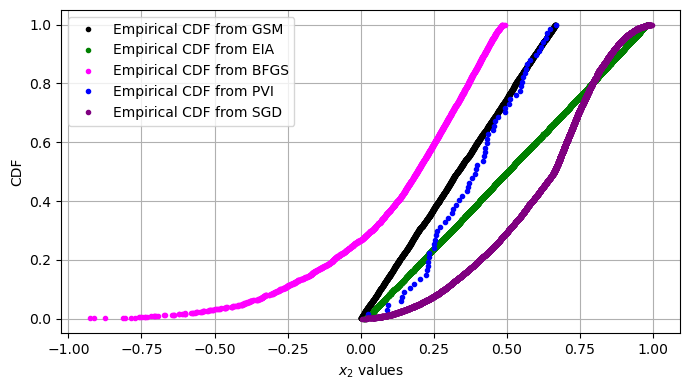

GSM
K-S Statistic: 0.0050
P-Value: 1.0000
Result: Fail to reject H0 → Sample follows Uniform(0.00023024829822082538,0.6664447471311562)

*********
EIA
K-S Statistic: 0.0117
P-Value: 0.1941
Result: Fail to reject H0 → Sample follows Uniform(0.010600323235231775,0.9843948168987442)

*********
BFGS
K-S Statistic: 0.3909
P-Value: 0.0000
Result: Reject H0 → Sample does NOT follow Uniform(-0.9276236541221851,0.49289692171190247)

*********
PVI
K-S Statistic: 0.1725
P-Value: 0.0327
Result: Reject H0 → Sample does NOT follow Uniform(0.024976077090483315,0.6666666604276872)

*********
SGD
K-S Statistic: 0.2101
P-Value: 0.0000
Result: Reject H0 → Sample does NOT follow Uniform(0.0038828898339974475,0.9960095513014167)

*********


In [312]:
# KS Test on y: 
# Number of samples
a,b= 1/2, 2/3
uniform_samples = np.random.uniform(low=a, high=b, size=len(x))
# uniform_samples= np.hstack((uniform_samples,9))
cdf_uniform= [get_cdf_of_uniform(i, a= a, b= b) for i in uniform_samples]

# Number of samples
n_samples = len(x)

# Generate uniform values in [0,1]
#uniform_samples = np.random.uniform(low=0.0, high=1.0, size=n_samples)

# Plotting the histogram of uniform samples
plt.figure(figsize=(7, 4))

# CDF Plot
sorted_samples = np.sort(y)
ecdfgsm= ECDF(ygsm) #np.arange(1, n_samples+1) / n_samples
ecdfeia= ECDF(yeia) #np.arange(1, n_samples+1) / n_samples
ecdfbfgs= ECDF(ybfgs) #np.arange(1, n_samples+1) / n_samples
ecdfpvi= ECDF(ypvi) #np.arange(1, n_samples+1) / n_samples
ecdfsgd= ECDF(ysgd)

plt.plot(ecdfgsm.x, ecdfgsm.y, marker='.', linestyle='none', label='Empirical CDF from GSM',c= 'black')
plt.plot(ecdfeia.x, ecdfeia.y, marker='.', linestyle='none', label='Empirical CDF from EIA',c= 'green')
plt.plot(ecdfbfgs.x, ecdfbfgs.y, marker='.', linestyle='none', label='Empirical CDF from BFGS',c= 'magenta')

plt.plot(ecdfpvi.x, ecdfpvi.y, marker='.', linestyle='none', label='Empirical CDF from PVI',c= 'blue')
plt.plot(ecdfsgd.x, ecdfsgd.y, marker='.', linestyle='none', label='Empirical CDF from SGD',c= 'purple')
# plt.plot([0.5, 1], [0.0, 1], 'r--', label='Uniform CDF')
# plt.plot(uniform_samples,cdf_uniform, 'r--', label='Uniform CDF')
# plt.title('CDF of Uniform Samples vs. Empiricc')
plt.xlabel('$x_2$ values')
plt.ylabel('CDF')
# plt.xlim([0, 1])
# plt.ylim([0, 1])
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('../KS-Plots/Ex9/all_ks_ex9_x2.png')
plt.show()


    
print("GSM")
KS_test(ygsm, min(ygsm), max(ygsm), alpha=0.05)
print("*********")
print("EIA")
KS_test(yeia, min(yeia), max(yeia), alpha=0.05)
print("*********")
print("BFGS")
KS_test(ybfgs, min(ybfgs), max(ybfgs), alpha=0.05)
print("*********")
print("PVI")
KS_test(ypvi, min(ypvi), max(ypvi), alpha=0.05)
print("*********")
print("SGD")
KS_test(ysgd, min(ysgd), max(ysgd), alpha=0.05)
print("*********")

In [313]:
nubmer_points_list= [100, 200,300,400,500,600,700,800,900,1000,1100,1200, 1300,1400,1500]

In [314]:
len(pdpgsm), len(pdpeia),len(pdpbfgs), len(pdppvi), len(pdpsgd)

(15, 15, 15, 15, 15)

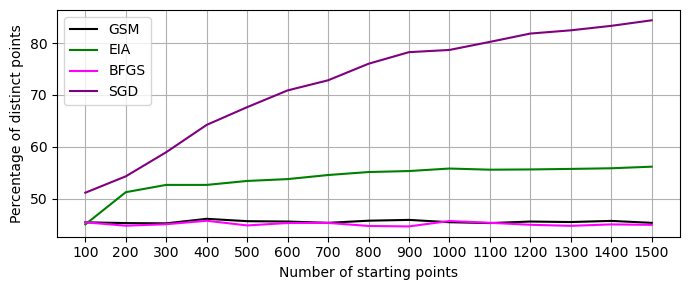

In [315]:
plt.figure(figsize=(7, 3))
plt.plot(nubmer_points_list, pdpgsm,label='GSM',c= 'black')
plt.plot(nubmer_points_list, pdpeia, label='EIA',c= 'green')
plt.plot(nubmer_points_list, pdpbfgs, label='BFGS',c= 'magenta')

# plt.plot(nubmer_points_list, pdppvi, label='PVI',c= 'blue')
plt.plot(nubmer_points_list, pdpsgd, label='SGD',c= 'purple')
# plt.plot([0.5, 1], [0.0, 1], 'r--', label='Uniform CDF')
# plt.title('CDF of Uniform Samples vs. Empiricc')
plt.xlabel('Number of starting points')
plt.ylabel('Percentage of distinct points')
plt.xticks(nubmer_points_list)
# plt.ylim([0, 1])
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('../KS-Plots/Ex9/ex9_npoints_pdp.png')
plt.show()

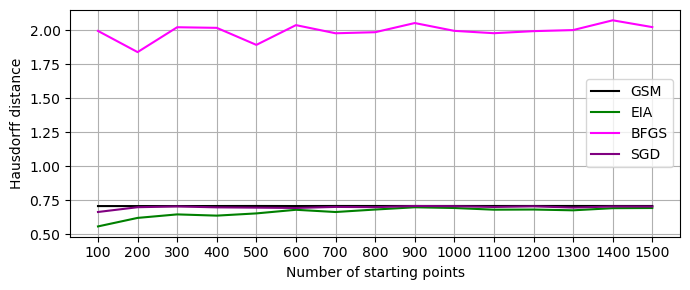

In [316]:
plt.figure(figsize=(7, 3))
plt.plot(nubmer_points_list, hdgsm,label='GSM',c= 'black')
plt.plot(nubmer_points_list, hdeia, label='EIA',c= 'green')
plt.plot(nubmer_points_list, hdbfgs, label='BFGS',c= 'magenta')

# plt.plot(nubmer_points_list, hdgpvi, label='PVI',c= 'blue')
plt.plot(nubmer_points_list, hdsgd, label='SGD',c= 'purple')
# plt.plot([0.5, 1], [0.0, 1], 'r--', label='Uniform CDF')
# plt.title('CDF of Uniform Samples vs. Empiricc')
plt.xlabel('Number of starting points')
plt.ylabel('Hausdorff distance')
plt.xticks(nubmer_points_list)
# plt.ylim([0, 1])
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('../KS-Plots/Ex9/ex9_npoints_hd.png')
plt.show()

In [317]:
hdsgd

[0.6627949569700013,
 0.6979874731869692,
 0.7036290996187904,
 0.696903369409315,
 0.6947953142874416,
 0.6925123988236255,
 0.7001458468475035,
 0.6983669131851391,
 0.7068463686554558,
 0.705348494330979,
 0.6997304015663441,
 0.704379324013775,
 0.695261910108045,
 0.7034186931560691,
 0.7029992168376737]

# Histograms

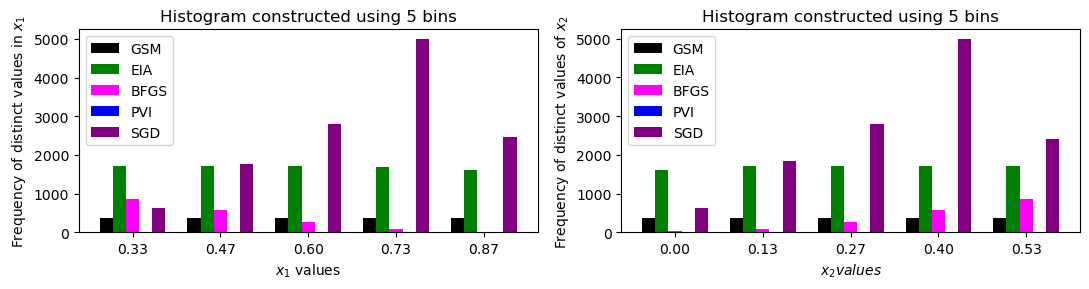

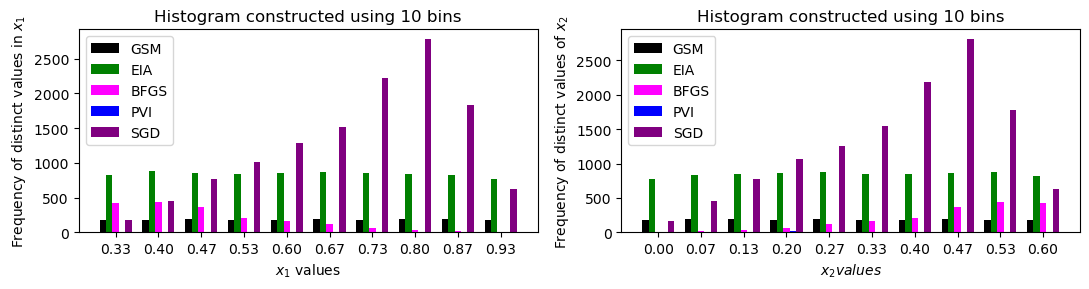

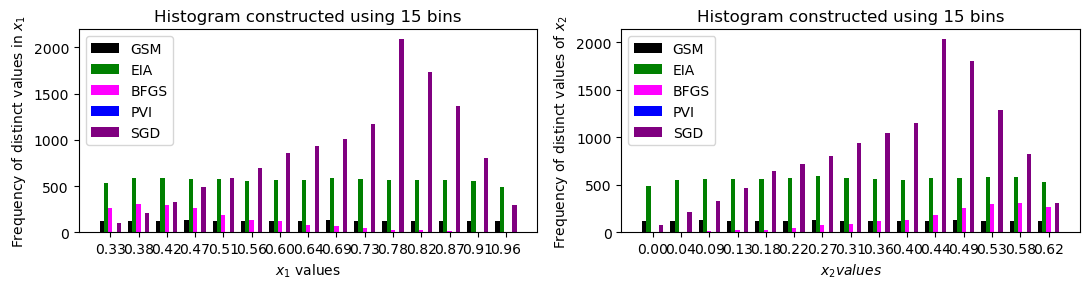

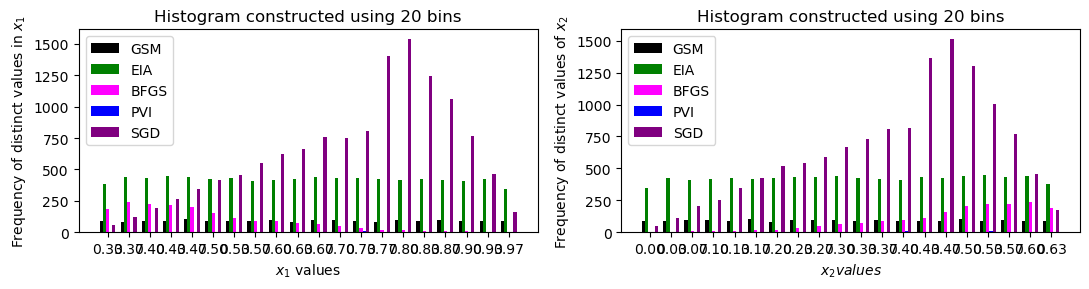

In [318]:
import matplotlib.pyplot as plt
import numpy as np

for n_bins in range(len(bins_list)):
    plt.figure(figsize=(11, 3))  # Increase the figure height for better readability
    
    width = 0.15  # Width of the bars
    
    # First subplot for x_hist_gsm and x_hist_eia
    plt.subplot(1, 2, 1)
    
    x = np.arange(len(x_hist_gsm[n_bins]))  # X locations for the groups
    
    barsgsm = plt.bar(x - 2*width, list(x_hist_gsm[n_bins].values()), width, align='center', color='black', label='GSM')
    barseia = plt.bar(x - width, list(x_hist_eia[n_bins].values()), width, align='center', color='green', label='EIA')
    barsbfgs = plt.bar(x, list(x_hist_bfgs[n_bins].values()), width, align='center', color='magenta', label='BFGS')
    barspvi = plt.bar(x + width, list(x_hist_pvi[n_bins].values()), width, align='center', color='blue', label='PVI')
    barssgd = plt.bar(x + 2*width, list(x_hist_sgd[n_bins].values()), width, align='center', color='purple', label='SGD')
    
    # Customize plot
    plt.xticks(x, ["{:.2f}".format(b) for b in x_part_gsm[n_bins][:-1]])
    plt.xlabel('$x_1$ values')
    plt.ylabel('Frequency of distinct values in $x_1$')
    plt.title('Histogram constructed using {} bins'.format(len(x_hist_gsm[n_bins])))
    plt.legend(loc='best', frameon=True, shadow=False)
    #plt.title('Histogram for n_bins= {}'.format(len(x_hist_gsm[n_bins])))
    # plt.legend(loc='upper right')
#     plt.grid(True)
    
    # Second subplot for y_hist_gsm and y_hist_eia
    plt.subplot(1, 2, 2)
    
    y = np.arange(len(y_hist_gsm[n_bins]))  # X locations for the groups
    
    barsgsm = plt.bar(y - 2*width, list(y_hist_gsm[n_bins].values()), width, align='center', color='black', label='GSM')
    barseia = plt.bar(y - width, list(y_hist_eia[n_bins].values()), width, align='center', color='green', label='EIA')
    barsbfgs = plt.bar(y, list(y_hist_bfgs[n_bins].values()), width, align='center', color='magenta', label='BFGS')
    barspvi = plt.bar(y + width, list(y_hist_pvi[n_bins].values()), width, align='center', color='blue', label='PVI')
    barssgd = plt.bar(y + 2*width, list(y_hist_sgd[n_bins].values()), width, align='center', color='purple', label='SGD')

    # Customize plot
    plt.xticks(y, ["{:.2f}".format(b) for b in y_part_gsm[n_bins][:-1]])
    plt.xlabel('$x_2 values$')
    plt.ylabel('Frequency of distinct values of $x_2$')
    plt.title('Histogram constructed using {} bins'.format(len(y_hist_gsm[n_bins])))
    plt.legend(loc='best', frameon=True, shadow=False)
    #plt.title('Histogram for n_bins= {}'.format(len(y_hist_gsm[n_bins])))
    # plt.legend(loc='upper right')
#     plt.grid(True)
    
    plt.tight_layout()
    # Uncomment the next line to save the plot
    plt.savefig('../KS-Plots/Ex9/'+'ex9_hist_bin'+str(bins_list[n_bins])+'.png')
    plt.show()


In [319]:
xeia

array([0.39411273, 0.09355891, 0.11845156, ..., 0.67315349, 0.33201178,
       0.33577849])

In [320]:
Ex8Sols= {
        "EIA":
                {
                    "hd": None, "pdp": None, "solutions": None
                },

     "SGD":{
        "hd":None, "pdp": None, "solutions":None
    },

     "GSM":{
        "hd":None, "pdp": None, "solutions":None
    },

     "PVI":{
        "hd":None, "pdp": None, "solutions":None
    },

     "BFGS":{
        "hd":None, "pdp": None, "solutions":None
    }



}

Algorithms= ["EIA", "SGD", "GSM", "PVI", "BFGS"]

HDResults= [hdeia, hdsgd, hdgsm, hdgpvi, hdbfgs]
PDPResults= [pdpeia, pdpsgd, pdpgsm, pdppvi, pdpbfgs]
# dataSol= [data_eia, data_sgd, data_gsm, data_pvi, data_bfgs]

for (idx, algo) in enumerate(Algorithms):

    Ex8Sols[algo]["hd"]= HDResults[idx]
    Ex8Sols[algo]["pdp"]= PDPResults[idx]
    # Ex4Sols[algo]["solutions"]= dataSol[idx]


import json

def convert_ndarray(obj):
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    raise TypeError(f"Object of type {type(obj)} is not JSON serializable")

with open("Ex8Sols.json", "w", encoding="utf-8") as f:
    json.dump(Ex8Sols, f, indent=4, default=convert_ndarray)


import json

with open("Ex8Sols.json", "r", encoding="utf-8") as f:
    Ex8Sols = json.load(f)

